# **Setup**

In [ ]:
# Installing packages
!pip install lime -q
!pip install ta -q


In [ ]:
# Importing Libraries
import pandas as pd
import numpy as np
import yfinance as yf
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')
from scipy.stats import norm

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
plt.style.use('seaborn-v0_8-darkgrid')

# Machine Learning
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report,
                             roc_auc_score, mean_squared_error, mean_absolute_error)
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb

# NLP and Feature Engineering
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch
import ta
import shap
from lime.lime_tabular import LimeTabularExplainer

# Financial Analysis
from scipy import stats
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller

# Data files
from google.colab import files

In [ ]:
# uploading files
uploaded = files.upload()

In [ ]:
# Now, lets check the data files.
files = {
    'cnbc': 'cnbc_headlines.csv',
    'guardian': 'guardian_headlines.csv',
    'reuters': 'reuters_headlines.csv',
    'events': 'Event_calendar.csv',
    'prices': 'FTSE 100 Prices 2019-2024.csv'
}

for name, file in files.items():
    try:
        df = pd.read_csv(file, nrows=3)
        print(f"\n{name.upper()} - Columns: {list(df.columns)}")
        print(f"Shape: {df.shape}")
    except Exception as e:
        print(f"\nError loading {name}: {e}")


CNBC - Columns: ['Headlines', 'Time', 'Description']
Shape: (3, 3)

GUARDIAN - Columns: ['Time', 'Headlines']
Shape: (3, 2)

REUTERS - Columns: ['Headlines', 'Time', 'Description']
Shape: (3, 3)

EVENTS - Columns: ['date', 'event_type', 'description', 'report_published']
Shape: (3, 4)

PRICES - Columns: ['date', 'adj close', 'close', 'high', 'low', 'open', 'volume', 'return']
Shape: (3, 8)


# **Data Loading**

In [ ]:
# Loading the news datasets
cnbc_df = pd.read_csv('cnbc_headlines.csv')
guardian_df = pd.read_csv('guardian_headlines.csv')
reuters_df = pd.read_csv('reuters_headlines.csv')

# Loading the event calendar
events_df = pd.read_csv('Event_calendar.csv')

# Loading the price data
prices_df = pd.read_csv('FTSE 100 Prices 2019-2024.csv')

# **Data Processing**

Standardizing News Data

In [ ]:
def preprocess_news_data(df, source_name):
    """Standardizing the news datasets"""
    # Create copy
    df_clean = df.copy()

    # Standardizing the column names
    df_clean.columns = [col.lower().strip() for col in df_clean.columns]

    # Ensuring that we have required columns
    if 'headlines' in df_clean.columns:
        df_clean.rename(columns={'headlines': 'headline'}, inplace=True)
    if 'time' in df_clean.columns:
        df_clean.rename(columns={'time': 'publish_date'}, inplace=True)

    # Converting the dates
    df_clean['publish_date'] = pd.to_datetime(df_clean['publish_date'], errors='coerce')

    # Removing the rows with invalid dates
    df_clean = df_clean.dropna(subset=['publish_date'])

    # Adding the source column
    df_clean['source'] = source_name

    # Extracting the date only. this is usefull for the daily aggregation.
    df_clean['date'] = df_clean['publish_date'].dt.date

    # Cleaning the headline text
    df_clean['headline'] = df_clean['headline'].astype(str).str.lower()
    df_clean['headline'] = df_clean['headline'].str.replace(r'[^\w\s]', ' ', regex=True)
    df_clean['headline'] = df_clean['headline'].str.replace(r'\s+', ' ', regex=True).str.strip()

    # Removing very short headlines that do not make any sense in the analysis
    df_clean = df_clean[df_clean['headline'].str.len() > 10]

    return df_clean

# Processing all the news sources
cnbc_clean = preprocess_news_data(cnbc_df, 'CNBC')
guardian_clean = preprocess_news_data(guardian_df, 'Guardian')
reuters_clean = preprocess_news_data(reuters_df, 'Reuters')

# Now, let's combine all the news sources into a single dataframe.
all_news = pd.concat([cnbc_clean, guardian_clean, reuters_clean], ignore_index=True)

# Good, now lets see how many headlines has been combined in total.
print(f"\nCombined News Data: {all_news.shape[0]:,} headlines")


Combined News Data: 53,330 headlines


Processing Event Calendar

In [ ]:
events_df['date'] = pd.to_datetime(events_df['date'], dayfirst=True).dt.date

 Processing Price Data

In [ ]:
# Converting date and ensure proper sorting
prices_df['date'] = pd.to_datetime(prices_df['date'], dayfirst=True).dt.date
prices_df = prices_df.sort_values('date')

# Filtering to match news timeline (Mar 2018 - July 2020)
start_date = pd.to_datetime('2018-03-01').date()
end_date = pd.to_datetime('2020-07-19').date()
prices_filtered = prices_df[(prices_df['date'] >= start_date) &
                           (prices_df['date'] <= end_date)].copy()

print(f"\nFiltered Price Data: {prices_filtered.shape[0]:,} trading days")

# Calculating additional returns if it is not present
if 'return' not in prices_filtered.columns:
    prices_filtered['return'] = prices_filtered['adj close'].pct_change()

# Creating target variable (next day's direction)
prices_filtered['target'] = (prices_filtered['return'].shift(-1) > 0).astype(int)

# Removing the last row, as it has no target value
prices_filtered = prices_filtered.dropna(subset=['target'])


Filtered Price Data: 403 trading days


# **Exploratory Data Analysis**

Temporal Analysis

In [ ]:
fig = make_subplots(
    rows=3, cols=1,
    subplot_titles=('News Volume Over Time', 'FTSE 100 Price Trend',
                   'Daily Returns Distribution'),
    vertical_spacing=0.1
)

# News volume
news_daily = all_news.groupby('date').size().reset_index(name='count')
fig.add_trace(
    go.Scatter(x=news_daily['date'], y=news_daily['count'],
               mode='lines', name='Daily News', line=dict(color='blue')),
    row=1, col=1
)

# Price trend
fig.add_trace(
    go.Scatter(x=prices_filtered['date'], y=prices_filtered['adj close'],
               mode='lines', name='FTSE 100', line=dict(color='green')),
    row=2, col=1
)

# Returns distribution
fig.add_trace(
    go.Histogram(x=prices_filtered['return'].dropna(),
                 name='Returns', nbinsx=50, marker_color='orange'),
    row=3, col=1
)

fig.update_layout(height=900, showlegend=True, title_text="Temporal Analysis Dashboard")
fig.show()

Sentiment Analysis with FinBERT

In [ ]:
# Loading the FinBERT model
tokenizer = AutoTokenizer.from_pretrained("yiyanghkust/finbert-tone")
model = AutoModelForSequenceClassification.from_pretrained("yiyanghkust/finbert-tone")

def get_sentiment(text):
    """Get sentiment using FinBERT"""
    try:
        inputs = tokenizer(text, return_tensors="pt", truncation=True, max_length=512)
        outputs = model(**inputs)
        predictions = torch.nn.functional.softmax(outputs.logits, dim=-1)

        # Return positive, negative, neutral probabilities
        return {
            'positive': predictions[0][0].item(),
            'negative': predictions[0][1].item(),
            'neutral': predictions[0][2].item()
        }
    except:
        return {'positive': 0, 'negative': 0, 'neutral': 1}

# Sampling the headlines for sentiment analysis (for performance)
sample_news = all_news.sample(min(1000, len(all_news)), random_state=42)
print(f"Analyzing sentiment for {len(sample_news)} sample headlines...")

sentiments = []
for i, row in sample_news.iterrows():
    if i % 100 == 0:
        print(f"  Processed {i}/{len(sample_news)} headlines...")
    sentiment = get_sentiment(row['headline'])
    sentiments.append(sentiment)

sentiment_df = pd.DataFrame(sentiments)
sample_news = pd.concat([sample_news.reset_index(drop=True), sentiment_df], axis=1)

# Calculating the compound sentiment score
sample_news['sentiment_score'] = sample_news['positive'] - sample_news['negative']

config.json:   0%|          | 0.00/533 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/439M [00:00<?, ?B/s]

Analyzing sentiment for 1000 sample headlines...


model.safetensors:   0%|          | 0.00/439M [00:00<?, ?B/s]

  Processed 21900/1000 headlines...
  Processed 46100/1000 headlines...
  Processed 32900/1000 headlines...
  Processed 14500/1000 headlines...
  Processed 7100/1000 headlines...
  Processed 19200/1000 headlines...
  Processed 37300/1000 headlines...
  Processed 6100/1000 headlines...
  Processed 34100/1000 headlines...
  Processed 30900/1000 headlines...


Sentiment Visualization

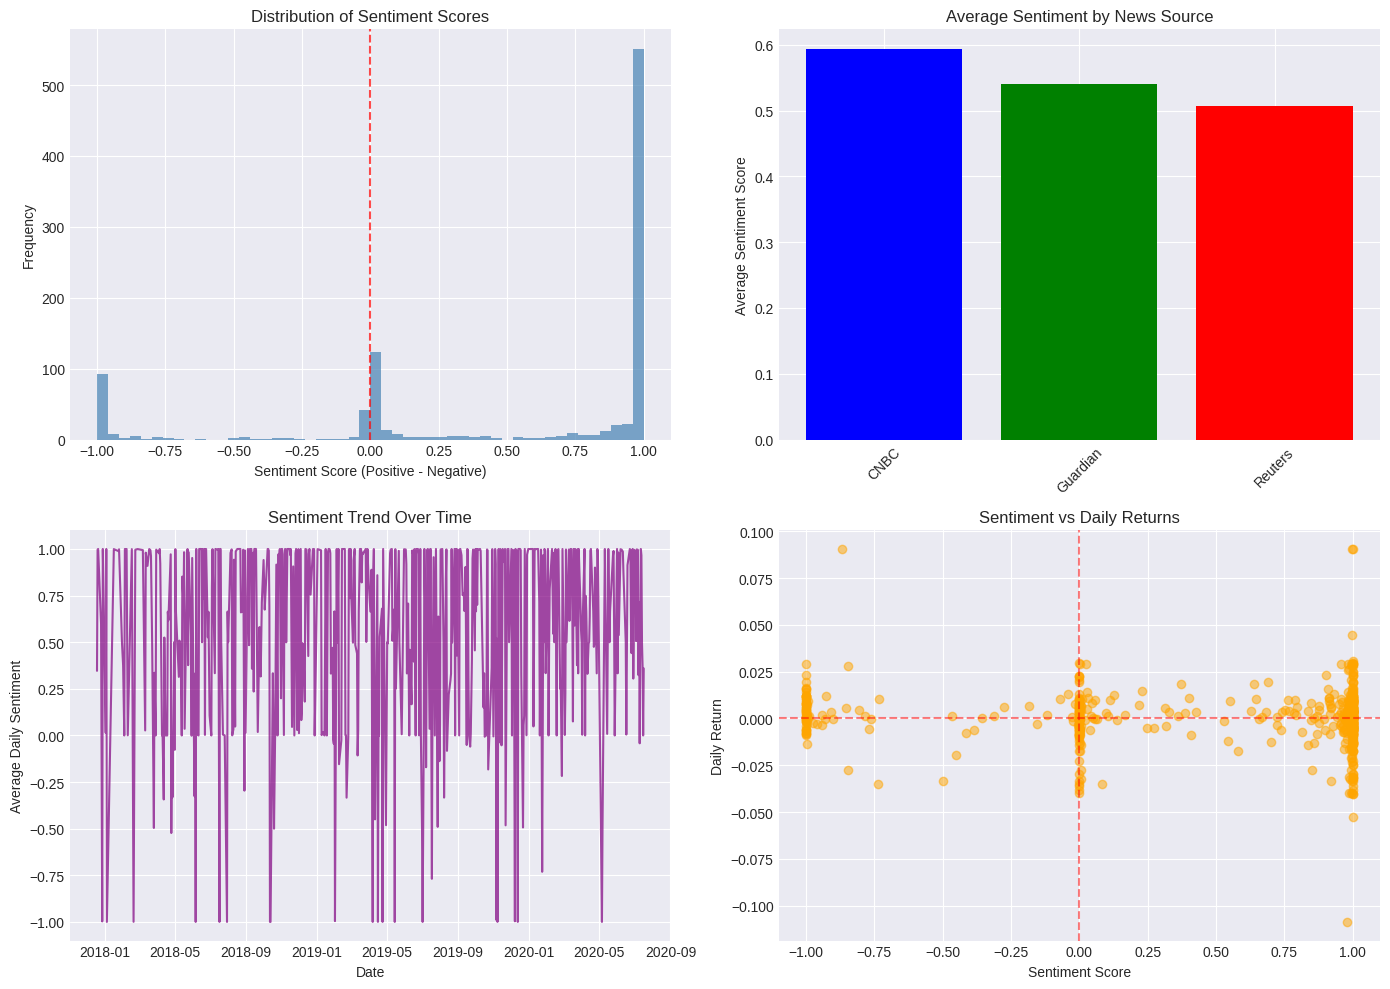

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Sentiment distribution
axes[0, 0].hist(sample_news['sentiment_score'], bins=50, alpha=0.7, color='steelblue')
axes[0, 0].set_title('Distribution of Sentiment Scores')
axes[0, 0].set_xlabel('Sentiment Score (Positive - Negative)')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].axvline(x=0, color='red', linestyle='--', alpha=0.7)

# Sentiment by source
sentiment_by_source = sample_news.groupby('source')['sentiment_score'].mean()
axes[0, 1].bar(sentiment_by_source.index, sentiment_by_source.values,
               color=['blue', 'green', 'red'])
axes[0, 1].set_title('Average Sentiment by News Source')
axes[0, 1].set_ylabel('Average Sentiment Score')
axes[0, 1].tick_params(axis='x', rotation=45)

# Sentiment over time
sample_news['date'] = pd.to_datetime(sample_news['date'], dayfirst=True)
prices_filtered['date'] = pd.to_datetime(prices_filtered['date'], dayfirst=True)

sentiment_daily = sample_news.groupby('date')['sentiment_score'].mean()
axes[1, 0].plot(sentiment_daily.index, sentiment_daily.values, color='purple', alpha=0.7)
axes[1, 0].set_title('Sentiment Trend Over Time')
axes[1, 0].set_xlabel('Date')
axes[1, 0].set_ylabel('Average Daily Sentiment')

# Sentiment vs Returns (scatter)
# We need to merge with price data for this
sample_news_with_price = pd.merge(sample_news, prices_filtered[['date', 'return']],
                                  on='date', how='left')
sample_news_with_price = sample_news_with_price.dropna(subset=['return'])
axes[1, 1].scatter(sample_news_with_price['sentiment_score'],
                   sample_news_with_price['return'],
                   alpha=0.5, color='orange')
axes[1, 1].set_title('Sentiment vs Daily Returns')
axes[1, 1].set_xlabel('Sentiment Score')
axes[1, 1].set_ylabel('Daily Return')
axes[1, 1].axhline(y=0, color='red', linestyle='--', alpha=0.5)
axes[1, 1].axvline(x=0, color='red', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

Event Analysis

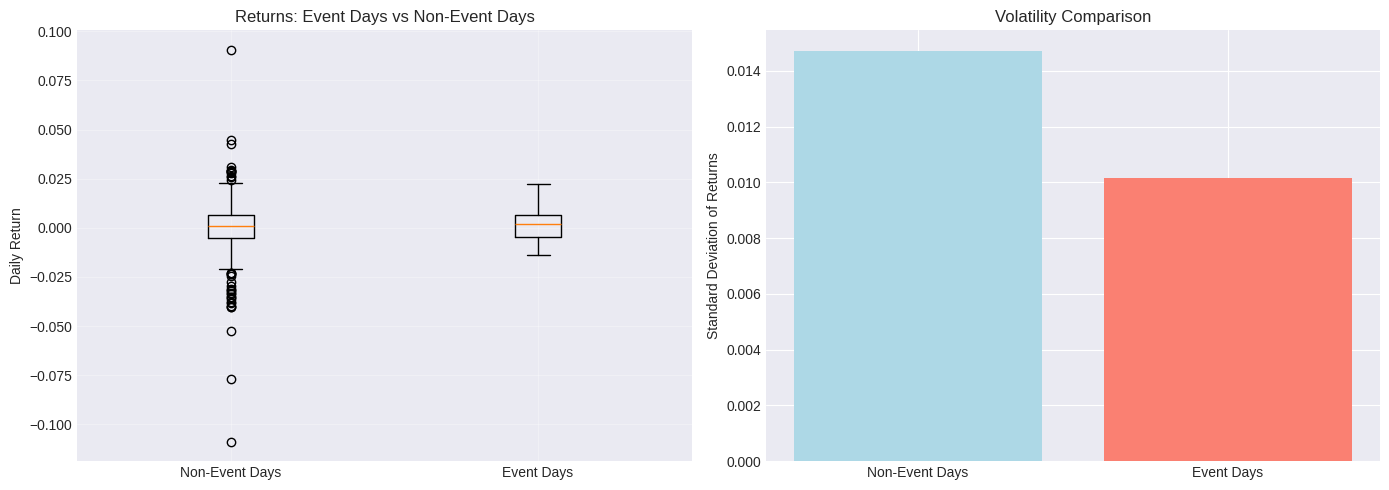

T-test for event vs non-event returns: t-stat = 0.685, p-value = 0.5058
No significant difference in returns


In [ ]:
# Merging the events with price data
events_df['date'] = pd.to_datetime(events_df['date'])
events_with_returns = pd.merge(events_df, prices_filtered[['date', 'return']],
                               on='date', how='inner')

if len(events_with_returns) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Returns on event days vs non-event days
    event_days = set(events_df['date'].dt.date)
    prices_filtered['is_event_day'] = prices_filtered['date'].isin(event_days)

    event_returns = prices_filtered[prices_filtered['is_event_day']]['return'].dropna()
    non_event_returns = prices_filtered[~prices_filtered['is_event_day']]['return'].dropna()

    axes[0].boxplot([non_event_returns, event_returns],
                    labels=['Non-Event Days', 'Event Days'])
    axes[0].set_title('Returns: Event Days vs Non-Event Days')
    axes[0].set_ylabel('Daily Return')
    axes[0].grid(True, alpha=0.3)

    # Volatility comparison
    event_volatility = event_returns.std() if len(event_returns) > 1 else 0
    non_event_volatility = non_event_returns.std() if len(non_event_returns) > 1 else 0

    axes[1].bar(['Non-Event Days', 'Event Days'],
                [non_event_volatility, event_volatility],
                color=['lightblue', 'salmon'])
    axes[1].set_title('Volatility Comparison')
    axes[1].set_ylabel('Standard Deviation of Returns')

    plt.tight_layout()
    plt.show()

    # Statistical test
    if len(event_returns) > 10 and len(non_event_returns) > 10:
        t_stat, p_value = stats.ttest_ind(event_returns, non_event_returns, equal_var=False)
        print(f"T-test for event vs non-event returns: t-stat = {t_stat:.3f}, p-value = {p_value:.4f}")
        if p_value < 0.05:
            print("Statistically significant difference in returns!")
        else:
            print("No significant difference in returns")

Correlation Analysis

Available features for correlation: ['return', 'volume', 'sma_5', 'sma_20', 'rsi', 'bb_high', 'bb_low', 'return_lag_1', 'return_lag_2', 'volume_change']


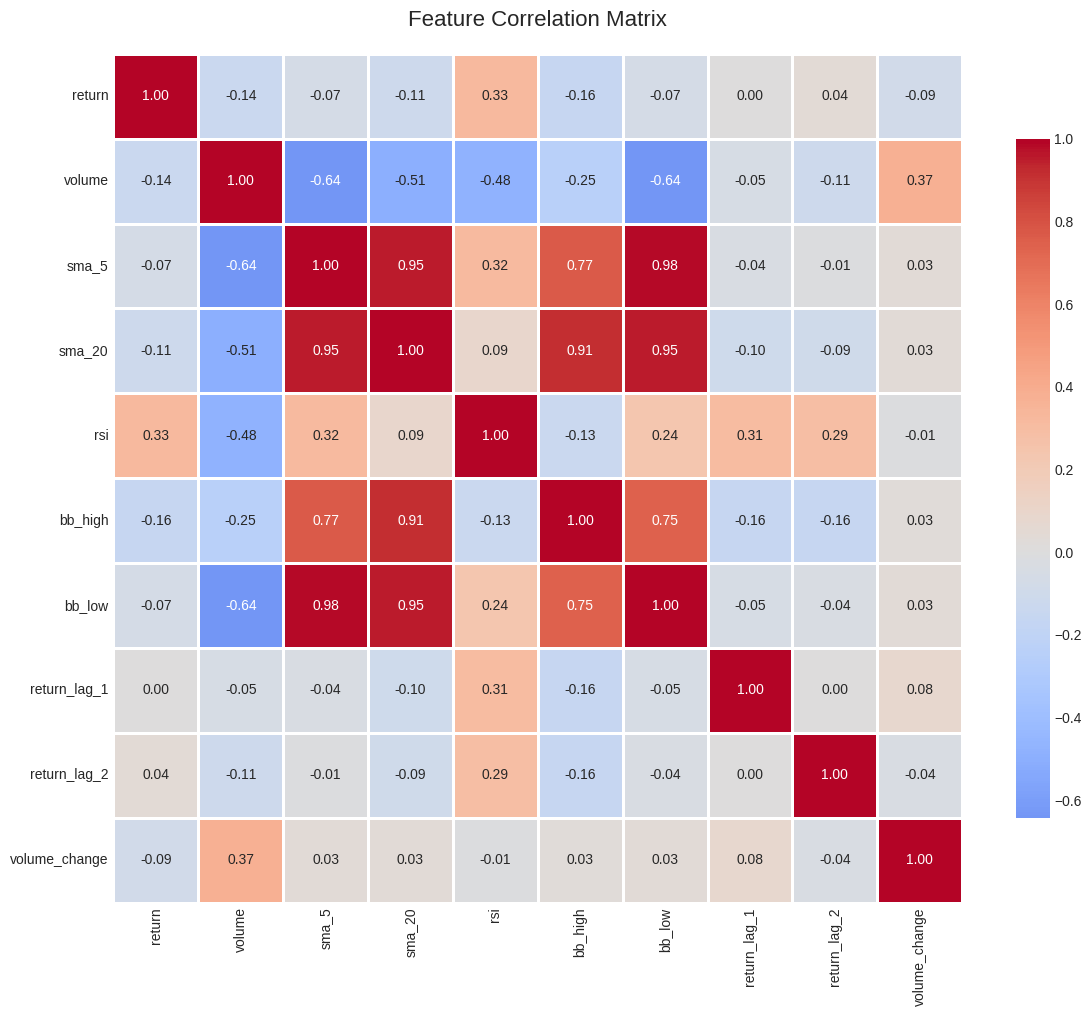


Top 10 Feature Correlations:
Feature1 Feature2  Correlation
   sma_5   bb_low     0.981215
  bb_low   sma_20     0.953726
  sma_20    sma_5     0.952075
 bb_high   sma_20     0.911853
   sma_5  bb_high     0.768217
 bb_high   bb_low     0.746224
  volume    sma_5    -0.642169
  bb_low   volume    -0.641388
  sma_20   volume    -0.507345
  volume      rsi    -0.477142


In [ ]:
# Preparign the features for correlation
analysis_df = prices_filtered.copy()

# Calculating the technical indicators FIRST
analysis_df['sma_5'] = ta.trend.sma_indicator(analysis_df['adj close'], window=5)
analysis_df['sma_20'] = ta.trend.sma_indicator(analysis_df['adj close'], window=20)
analysis_df['rsi'] = ta.momentum.rsi(analysis_df['adj close'], window=14)

# Calculating the Bollinger Bands
from ta.volatility import BollingerBands

# Initializing the Bollinger Bands indicator
bb_indicator = BollingerBands(close=analysis_df['adj close'], window=20, window_dev=2)
analysis_df['bb_high'] = bb_indicator.bollinger_hband()
analysis_df['bb_low'] = bb_indicator.bollinger_lband()
analysis_df['bb_middle'] = bb_indicator.bollinger_mavg()

# Adding lagged returns
for lag in [1, 2, 3, 5, 10]:
    analysis_df[f'return_lag_{lag}'] = analysis_df['return'].shift(lag)

# Adding volume features
analysis_df['volume_change'] = analysis_df['volume'].pct_change()
analysis_df['volume_ma5'] = analysis_df['volume'].rolling(5).mean()

# Droping NA values for correlation
corr_df = analysis_df.dropna()

# Selecting the key features for correlation matrix
corr_features = ['return', 'volume', 'sma_5', 'sma_20', 'rsi', 'bb_high', 'bb_low',
                 'return_lag_1', 'return_lag_2', 'volume_change']

# Checking if all features exist
available_features = [f for f in corr_features if f in corr_df.columns]
print(f"Available features for correlation: {available_features}")

if len(available_features) >= 2:
    corr_matrix = corr_df[available_features].corr()

    # Ploting correlation heatmap
    plt.figure(figsize=(12, 10))
    sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
                center=0, square=True, linewidths=1, cbar_kws={"shrink": 0.8})
    plt.title('Feature Correlation Matrix', fontsize=16, pad=20)
    plt.tight_layout()
    plt.show()

    # Printing strongest correlations
    print("\nTop 10 Feature Correlations:")
    corr_pairs = corr_matrix.unstack()
    sorted_pairs = corr_pairs.sort_values(key=abs, ascending=False)

    # Removing self-correlations and duplicates
    unique_pairs = pd.DataFrame(sorted_pairs).reset_index()
    unique_pairs.columns = ['Feature1', 'Feature2', 'Correlation']
    unique_pairs = unique_pairs[unique_pairs['Feature1'] != unique_pairs['Feature2']]

    # Geting the unique pairs
    seen = set()
    top_correlations = []
    for idx, row in unique_pairs.iterrows():
        pair = tuple(sorted([row['Feature1'], row['Feature2']]))
        if pair not in seen:
            seen.add(pair)
            top_correlations.append(row)
            if len(top_correlations) >= 10:
                break

    top_corr_df = pd.DataFrame(top_correlations)
    print(top_corr_df.to_string(index=False))
else:
# Let's debug this to find where the error is
    print("Not enough features available for correlation matrix")
    print(f"Expected at least 2 features, got {len(available_features)}")

    # Printing the available features
    if len(available_features) > 0:
        print(f"\nAvailable features: {available_features}")
        # Simple pairwise correlations
        for i in range(len(available_features)):
            for j in range(i+1, len(available_features)):
                feat1 = available_features[i]
                feat2 = available_features[j]
                if feat1 in corr_df.columns and feat2 in corr_df.columns:
                    corr_val = corr_df[feat1].corr(corr_df[feat2])
                    print(f"{feat1} vs {feat2}: {corr_val:.3f}")

# **Feature Engineering**

Creating comprehensive feature set

In [ ]:
# Creating the comprehensive feature set
features_df = prices_filtered.copy()

# Technical Indicators
features_df['returns_5d'] = features_df['adj close'].pct_change(5)
features_df['returns_20d'] = features_df['adj close'].pct_change(20)
features_df['volatility_20d'] = features_df['return'].rolling(20).std()
features_df['volume_ratio'] = features_df['volume'] / features_df['volume'].rolling(20).mean()

# Moving Averages
features_df['sma_5'] = ta.trend.sma_indicator(features_df['adj close'], window=5)
features_df['sma_20'] = ta.trend.sma_indicator(features_df['adj close'], window=20)
features_df['ema_12'] = ta.trend.ema_indicator(features_df['adj close'], window=12)

# Momentum Indicators
features_df['rsi'] = ta.momentum.rsi(features_df['adj close'], window=14)
features_df['macd'] = ta.trend.macd(features_df['adj close'])

# Stochastic - handle potential errors
try:
    features_df['stoch_k'] = ta.momentum.stoch(features_df['high'], features_df['low'],
                                               features_df['adj close'])
except:
    print("Could not calculate Stochastic Oscillator")
    features_df['stoch_k'] = np.nan

# Volatility Indicators
features_df['atr'] = ta.volatility.average_true_range(features_df['high'],
                                                      features_df['low'],
                                                      features_df['adj close'])

# Calculating Bollinger Bands
bb_indicator = BollingerBands(close=features_df['adj close'], window=20, window_dev=2)
features_df['bb_high'] = bb_indicator.bollinger_hband()
features_df['bb_low'] = bb_indicator.bollinger_lband()
features_df['bb_middle'] = bb_indicator.bollinger_mavg()

# Calculating BB width safely
features_df['bb_width'] = np.where(
    features_df['sma_20'].notna(),
    (features_df['bb_high'] - features_df['bb_low']) / features_df['sma_20'],
    np.nan
)

# Lagged Features
for lag in [1, 2, 3, 5]:
    features_df[f'return_lag_{lag}'] = features_df['return'].shift(lag)
    features_df[f'volume_lag_{lag}'] = features_df['volume'].shift(lag)

# Event Features
event_dates = set(events_df['date'].dt.date if hasattr(events_df['date'], 'dt')
                  else set(pd.to_datetime(events_df['date']).dt.date))
features_df['is_boe_meeting'] = features_df['date'].isin(event_dates).astype(int)

# News Sentiment Features
if 'sentiment_score' in sample_news.columns:
    sentiment_daily_avg = sample_news.groupby('date')['sentiment_score'].mean().reset_index()
    sentiment_daily_avg.columns = ['date', 'avg_sentiment']

    # Ensuring date types match
    sentiment_daily_avg['date'] = pd.to_datetime(sentiment_daily_avg['date']).dt.date
    features_df['date'] = pd.to_datetime(features_df['date']).dt.date

    features_df = pd.merge(features_df, sentiment_daily_avg, on='date', how='left')
    features_df['avg_sentiment'] = features_df['avg_sentiment'].fillna(0)

    # Creating additional sentiment features
    features_df['sentiment_momentum'] = features_df['avg_sentiment'].rolling(5).mean()
    features_df['sentiment_volatility'] = features_df['avg_sentiment'].rolling(10).std()
else:
    print("No sentiment data available - skipping sentiment features")
    features_df['avg_sentiment'] = 0
    features_df['sentiment_momentum'] = 0
    features_df['sentiment_volatility'] = 0

print(f"Created {features_df.shape[1]} features for modeling")
print(f"Features: {list(features_df.columns)}")

# Checking for any missing values
missing_values = features_df.isnull().sum()
if missing_values.sum() > 0:
    print(f"\nMissing values found:")
    for col, missing in missing_values[missing_values > 0].items():
        print(f"  {col}: {missing} missing values ({missing/len(features_df):.1%})")

    # Forward filling for technical indicators
    numeric_cols = features_df.select_dtypes(include=[np.number]).columns
    features_df[numeric_cols] = features_df[numeric_cols].fillna(method='ffill').fillna(method='bfill')
    print("Missing values handled with forward/backward fill")

Created 37 features for modeling
Features: ['date', 'adj close', 'close', 'high', 'low', 'open', 'volume', 'return', 'target', 'is_event_day', 'returns_5d', 'returns_20d', 'volatility_20d', 'volume_ratio', 'sma_5', 'sma_20', 'ema_12', 'rsi', 'macd', 'stoch_k', 'atr', 'bb_high', 'bb_low', 'bb_middle', 'bb_width', 'return_lag_1', 'volume_lag_1', 'return_lag_2', 'volume_lag_2', 'return_lag_3', 'volume_lag_3', 'return_lag_5', 'volume_lag_5', 'is_boe_meeting', 'avg_sentiment', 'sentiment_momentum', 'sentiment_volatility']

Missing values found:
  return: 1 missing values (0.2%)
  returns_5d: 5 missing values (1.2%)
  returns_20d: 20 missing values (5.0%)
  volatility_20d: 20 missing values (5.0%)
  volume_ratio: 19 missing values (4.7%)
  sma_5: 4 missing values (1.0%)
  sma_20: 19 missing values (4.7%)
  ema_12: 11 missing values (2.7%)
  rsi: 13 missing values (3.2%)
  macd: 25 missing values (6.2%)
  stoch_k: 13 missing values (3.2%)
  bb_high: 19 missing values (4.7%)
  bb_low: 19 missi

Feature Selection

In [ ]:
# Removing the highly correlated features
corr_matrix = features_df.select_dtypes(include=[np.number]).corr().abs()
upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop = [column for column in upper_tri.columns if any(upper_tri[column] > 0.95)]

if to_drop:
    print(f"Removing highly correlated features: {to_drop}")
    features_df = features_df.drop(columns=to_drop)

Removing highly correlated features: ['close', 'high', 'low', 'open', 'sma_5', 'sma_20', 'ema_12', 'atr']


# **Modeling**

Prepare data for modeling

In [ ]:
modeling_df = features_df.dropna().copy()

# Defining the features and target
X = modeling_df.drop(columns=['date', 'target', 'adj close', 'close', 'high', 'low', 'open'])
y = modeling_df['target']

print(f"Final dataset for modeling: {X.shape[0]} samples, {X.shape[1]} features")
print(f"Class distribution: {y.value_counts().to_dict()}")

Final dataset for modeling: 403 samples, 30 features
Class distribution: {1: 217, 0: 186}


Time-series split

In [ ]:
tscv = TimeSeriesSplit(n_splits=5)
train_test_splits = list(tscv.split(X))

Scale features

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

Train-Test Split (last 20% for testing)

In [ ]:
split_idx = int(len(X) * 0.8)
X_train, X_test = X_scaled[:split_idx], X_scaled[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

print(f"\nTraining set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")


Training set: 322 samples
Test set: 81 samples


Baseline Models

In [ ]:
# Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

# XGBoost
xgb_model = xgb.XGBClassifier(n_estimators=100, learning_rate=0.1,
                              random_state=42, use_label_encoder=False)
xgb_model.fit(X_train, y_train)
xgb_pred = xgb_model.predict(X_test)

Model Evaluation


Random Forest Performance:
  Accuracy:  0.494
  Precision: 0.600
  Recall:    0.383
  F1-Score:  0.468
  ROC-AUC:   0.588


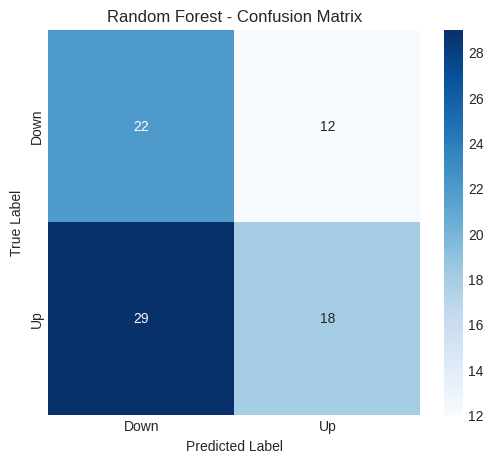


XGBoost Performance:
  Accuracy:  0.654
  Precision: 0.686
  Recall:    0.745
  F1-Score:  0.714
  ROC-AUC:   0.711


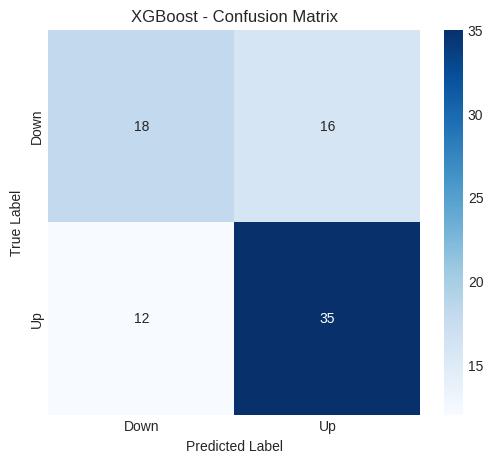


MODEL COMPARISON:
        Model  Accuracy  Precision   Recall  F1-Score  ROC-AUC
Random Forest  0.493827   0.600000 0.382979  0.467532 0.588235
      XGBoost  0.654321   0.686275 0.744681  0.714286 0.710889


In [ ]:
def evaluate_model(name, y_true, y_pred, y_prob=None):
    """Comprehensive model evaluation"""
    metrics = {
        'Model': name,
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred),
        'Recall': recall_score(y_true, y_pred),
        'F1-Score': f1_score(y_true, y_pred),
        'ROC-AUC': roc_auc_score(y_true, y_prob) if y_prob is not None else None
    }

    print(f"\n{name} Performance:")
    print(f"  Accuracy:  {metrics['Accuracy']:.3f}")
    print(f"  Precision: {metrics['Precision']:.3f}")
    print(f"  Recall:    {metrics['Recall']:.3f}")
    print(f"  F1-Score:  {metrics['F1-Score']:.3f}")
    if metrics['ROC-AUC']:
        print(f"  ROC-AUC:   {metrics['ROC-AUC']:.3f}")

    # Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Down', 'Up'],
                yticklabels=['Down', 'Up'])
    plt.title(f'{name} - Confusion Matrix')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.show()

    return metrics

# Evaluating the models
rf_metrics = evaluate_model('Random Forest', y_test, rf_pred, rf_model.predict_proba(X_test)[:, 1])
xgb_metrics = evaluate_model('XGBoost', y_test, xgb_pred, xgb_model.predict_proba(X_test)[:, 1])

# Comparing the models
comparison_df = pd.DataFrame([rf_metrics, xgb_metrics])
print("\nMODEL COMPARISON:")
print(comparison_df.to_string(index=False))

# **Explainable AI (XAI)**

SHAP Analysis

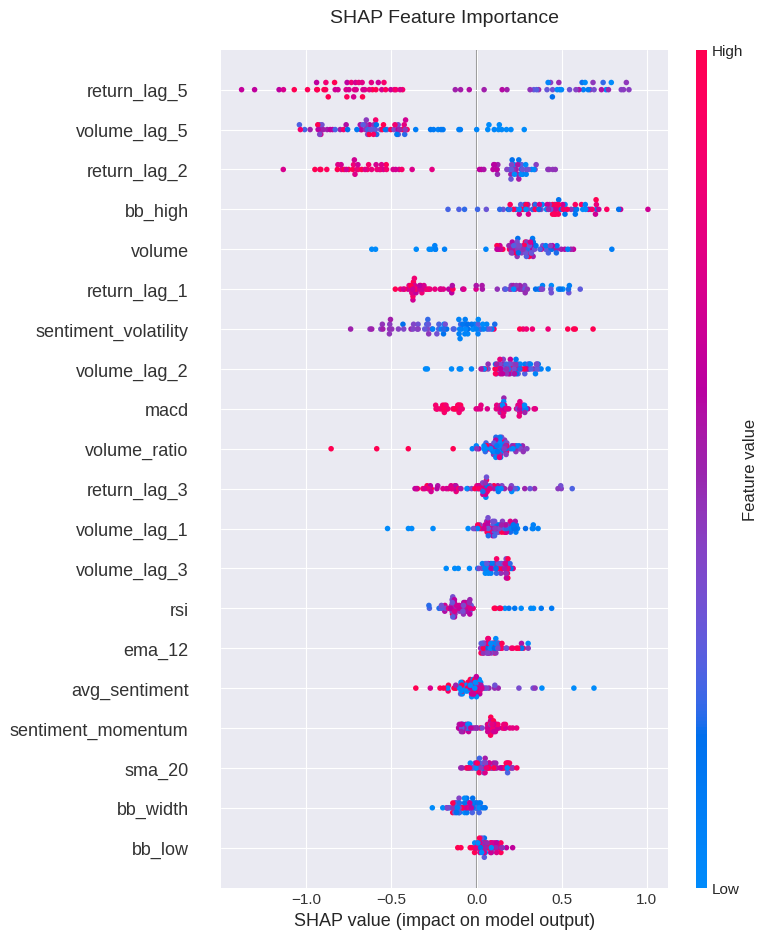


SHAP Force Plot for Individual Prediction:


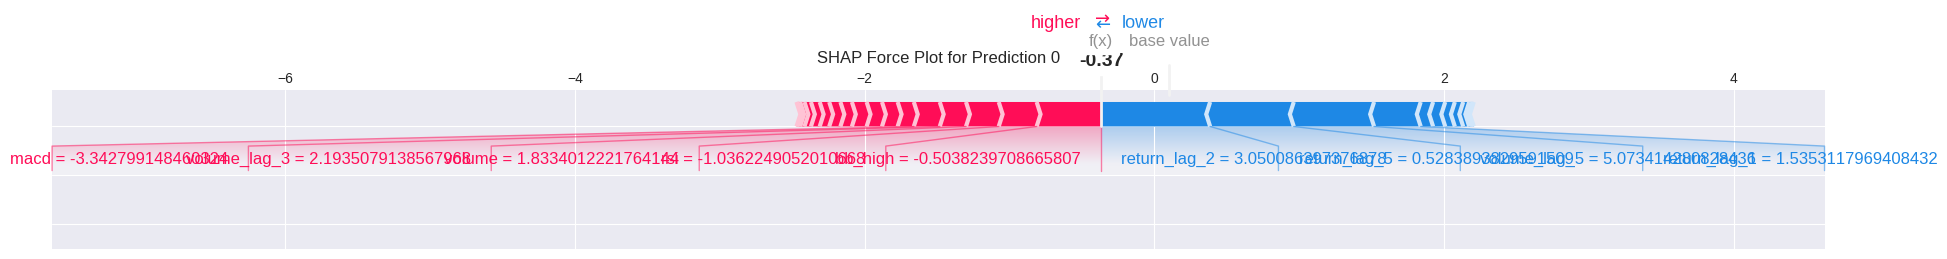

In [ ]:
# Creating the SHAP explainer
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test[:100])  # Use subset for speed

# Summary plot
shap.summary_plot(shap_values, X_test[:100], feature_names=X.columns,
                  show=False)
plt.title('SHAP Feature Importance', fontsize=14, pad=20)
plt.tight_layout()
plt.show()

# Forcing the plot for a specific prediction
print("\nSHAP Force Plot for Individual Prediction:")
sample_idx = 0
shap.force_plot(explainer.expected_value, shap_values[sample_idx],
                X_test[sample_idx], feature_names=X.columns,
                matplotlib=True, show=False)
plt.title(f'SHAP Force Plot for Prediction {sample_idx}', fontsize=12)
plt.tight_layout()
plt.show()

LIME Analysis

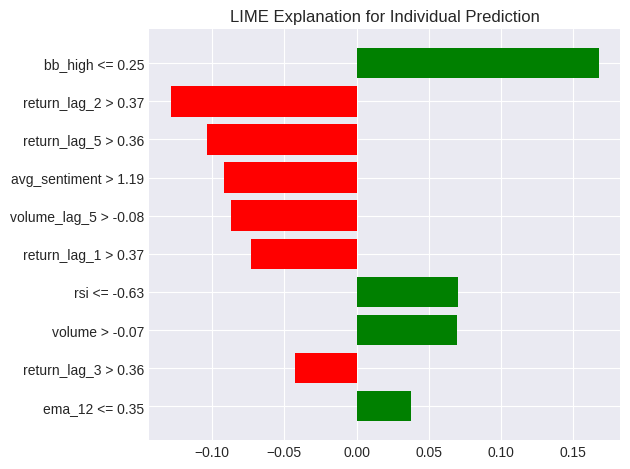


LIME Feature Contributions:
  bb_high <= 0.25: 0.1675
  return_lag_2 > 0.37: -0.1288
  return_lag_5 > 0.36: -0.1039
  avg_sentiment > 1.19: -0.0915
  volume_lag_5 > -0.08: -0.0873
  return_lag_1 > 0.37: -0.0729
  rsi <= -0.63: 0.0702
  volume > -0.07: 0.0696
  return_lag_3 > 0.36: -0.0429
  ema_12 <= 0.35: 0.0377


In [ ]:
lime_explainer = LimeTabularExplainer(
    X_train,
    feature_names=X.columns.tolist(),
    class_names=['Down', 'Up'],
    mode='classification'
)

# Explaining specific prediction
exp = lime_explainer.explain_instance(X_test[0], xgb_model.predict_proba, num_features=10)

# Displaying LIME explanation
fig = exp.as_pyplot_figure()
plt.title('LIME Explanation for Individual Prediction', fontsize=12)
plt.tight_layout()
plt.show()

print("\nLIME Feature Contributions:")
for feature, weight in exp.as_list():
    print(f"  {feature}: {weight:.4f}")

# Trading Strategy Backtest

Trading strategy based on predictions

In [ ]:
# Checking if we have data for backtesting
print(f"Modeling dataframe shape: {modeling_df.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_test shape: {y_test.shape}")

# Creating backtest dataframe
if len(modeling_df) > split_idx and len(xgb_pred) > 0:
    # Get the test period data
    backtest_df = modeling_df.iloc[split_idx:].copy()
    backtest_df = backtest_df.reset_index(drop=True)

    # Making sure we have the same number of predictions as test data
    if len(backtest_df) == len(xgb_pred):
        # Adding predictions
        backtest_df['prediction'] = xgb_pred
        backtest_df['probability'] = xgb_model.predict_proba(X_test)[:, 1]

        print(f"\nBacktest dataframe created with {len(backtest_df)} rows")
        print(f"Date range: {backtest_df['date'].min()} to {backtest_df['date'].max()}")

        # Ensuring 'date' column is datetime
        backtest_df['date'] = pd.to_datetime(backtest_df['date'], errors='coerce')

        # Strategy: Buy when prediction is 1, hold for 1 day
        backtest_df['position'] = 0
        backtest_df.loc[backtest_df['prediction'] == 1, 'position'] = 1

        # Ensuring we have returns column
        if 'return' not in backtest_df.columns:
            print("'return' column not found, calculating from 'adj close'")
            backtest_df['return'] = backtest_df['adj close'].pct_change()

        # Calculating strategy returns
        backtest_df['return'] = backtest_df['return'].fillna(0)
        backtest_df['next_day_return'] = backtest_df['return'].shift(-1).fillna(0)

        # Strategy return: position * next day's return
        backtest_df['strategy_return'] = backtest_df['position'] * backtest_df['next_day_return']

        # Benchmark: Buy and hold (always invested)
        backtest_df['benchmark_return'] = backtest_df['next_day_return']

        # Removing any remaining NaN values
        backtest_df = backtest_df.dropna(subset=['strategy_return', 'benchmark_return'])

        if len(backtest_df) > 0:
            print(f"{len(backtest_df)} valid rows for backtesting")

            # Calculating cumulative returns
            backtest_df['cumulative_strategy'] = (1 + backtest_df['strategy_return']).cumprod()
            backtest_df['cumulative_benchmark'] = (1 + backtest_df['benchmark_return']).cumprod()

Modeling dataframe shape: (403, 37)
X_test shape: (81, 30)
y_test shape: (81,)

Backtest dataframe created with 81 rows
Date range: 2020-03-27 to 2020-07-17
81 valid rows for backtesting


Perfomance Metrics

In [ ]:
        total_strategy_return = backtest_df['cumulative_strategy'].iloc[-1] - 1
        total_benchmark_return = backtest_df['cumulative_benchmark'].iloc[-1] - 1

        # Annualized returns
        trading_days = len(backtest_df)
        years = trading_days / 252  # Approximate trading days in a year
        annualized_strategy = (1 + total_strategy_return) ** (1/years) - 1
        annualized_benchmark = (1 + total_benchmark_return) ** (1/years) - 1

        # Sharpe Ratio
        strategy_sharpe = backtest_df['strategy_return'].mean() / backtest_df['strategy_return'].std() * np.sqrt(252) if backtest_df['strategy_return'].std() > 0 else 0
        benchmark_sharpe = backtest_df['benchmark_return'].mean() / backtest_df['benchmark_return'].std() * np.sqrt(252) if backtest_df['benchmark_return'].std() > 0 else 0

        # Maximum Drawdown
        def calculate_max_drawdown(cumulative_returns):
            running_max = np.maximum.accumulate(cumulative_returns)
            drawdown = (cumulative_returns - running_max) / running_max
            return drawdown.min()

        strategy_dd = calculate_max_drawdown(backtest_df['cumulative_strategy'])
        benchmark_dd = calculate_max_drawdown(backtest_df['cumulative_benchmark'])

        # Win rate
        win_rate_strategy = (backtest_df['strategy_return'] > 0).mean()
        win_rate_benchmark = (backtest_df['benchmark_return'] > 0).mean()


        print(f"\nBACKTEST PERIOD:")
        print(f"  Start Date:      {backtest_df['date'].min().date()}")
        print(f"  End Date:        {backtest_df['date'].max().date()}")
        print(f"  Trading Days:    {trading_days}")
        print(f"  Approx Years:    {years:.2f}")

        print(f"\nRETURN METRICS:")
        print(f"  Strategy Return:     {total_strategy_return:+.2%}")
        print(f"  Benchmark Return:    {total_benchmark_return:+.2%}")
        print(f"  Strategy Annualized: {annualized_strategy:+.2%}")
        print(f"  Benchmark Annualized:{annualized_benchmark:+.2%}")

        print(f"\nRISK METRICS:")
        print(f"  Strategy Sharpe:     {strategy_sharpe:.3f}")
        print(f"  Benchmark Sharpe:    {benchmark_sharpe:.3f}")
        print(f"  Strategy Max DD:     {strategy_dd:+.2%}")
        print(f"  Benchmark Max DD:    {benchmark_dd:+.2%}")
        print(f"  Strategy Volatility: {backtest_df['strategy_return'].std()*np.sqrt(252):.2%}")
        print(f"  Benchmark Volatility:{backtest_df['benchmark_return'].std()*np.sqrt(252):.2%}")

        print(f"\nSTRATEGY STATISTICS:")
        print(f"  Strategy Win Rate:   {win_rate_strategy:.1%}")
        print(f"  Benchmark Win Rate:  {win_rate_benchmark:.1%}")
        print(f"  Number of Trades:    {(backtest_df['position'].diff() != 0).sum()}")
        print(f"  Avg Trade Return:    {backtest_df['strategy_return'].mean():.4%}")

        # Profit Factor
        gross_profit = backtest_df[backtest_df['strategy_return'] > 0]['strategy_return'].sum()
        gross_loss = abs(backtest_df[backtest_df['strategy_return'] < 0]['strategy_return'].sum())
        profit_factor = gross_profit / gross_loss if gross_loss != 0 else np.inf
        print(f"  Profit Factor:       {profit_factor:.2f}")

        # Information Ratio
        excess_returns = backtest_df['strategy_return'] - backtest_df['benchmark_return']
        information_ratio = excess_returns.mean() / excess_returns.std() * np.sqrt(252) if excess_returns.std() > 0 else 0
        print(f"  Information Ratio:   {information_ratio:.3f}")


BACKTEST PERIOD:
  Start Date:      2020-03-27
  End Date:        2020-07-17
  Trading Days:    81
  Approx Years:    0.32

RETURN METRICS:
  Strategy Return:     +36.19%
  Benchmark Return:    +22.14%
  Strategy Annualized: +161.43%
  Benchmark Annualized:+86.29%

RISK METRICS:
  Strategy Sharpe:     4.430
  Benchmark Sharpe:    2.346
  Strategy Max DD:     -7.54%
  Benchmark Max DD:    -6.70%
  Strategy Volatility: 22.29%
  Benchmark Volatility:28.24%

STRATEGY STATISTICS:
  Strategy Win Rate:   43.2%
  Benchmark Win Rate:  58.0%
  Number of Trades:    47
  Avg Trade Return:    0.3918%
  Profit Factor:       2.43
  Information Ratio:   1.961


Visualization (1)

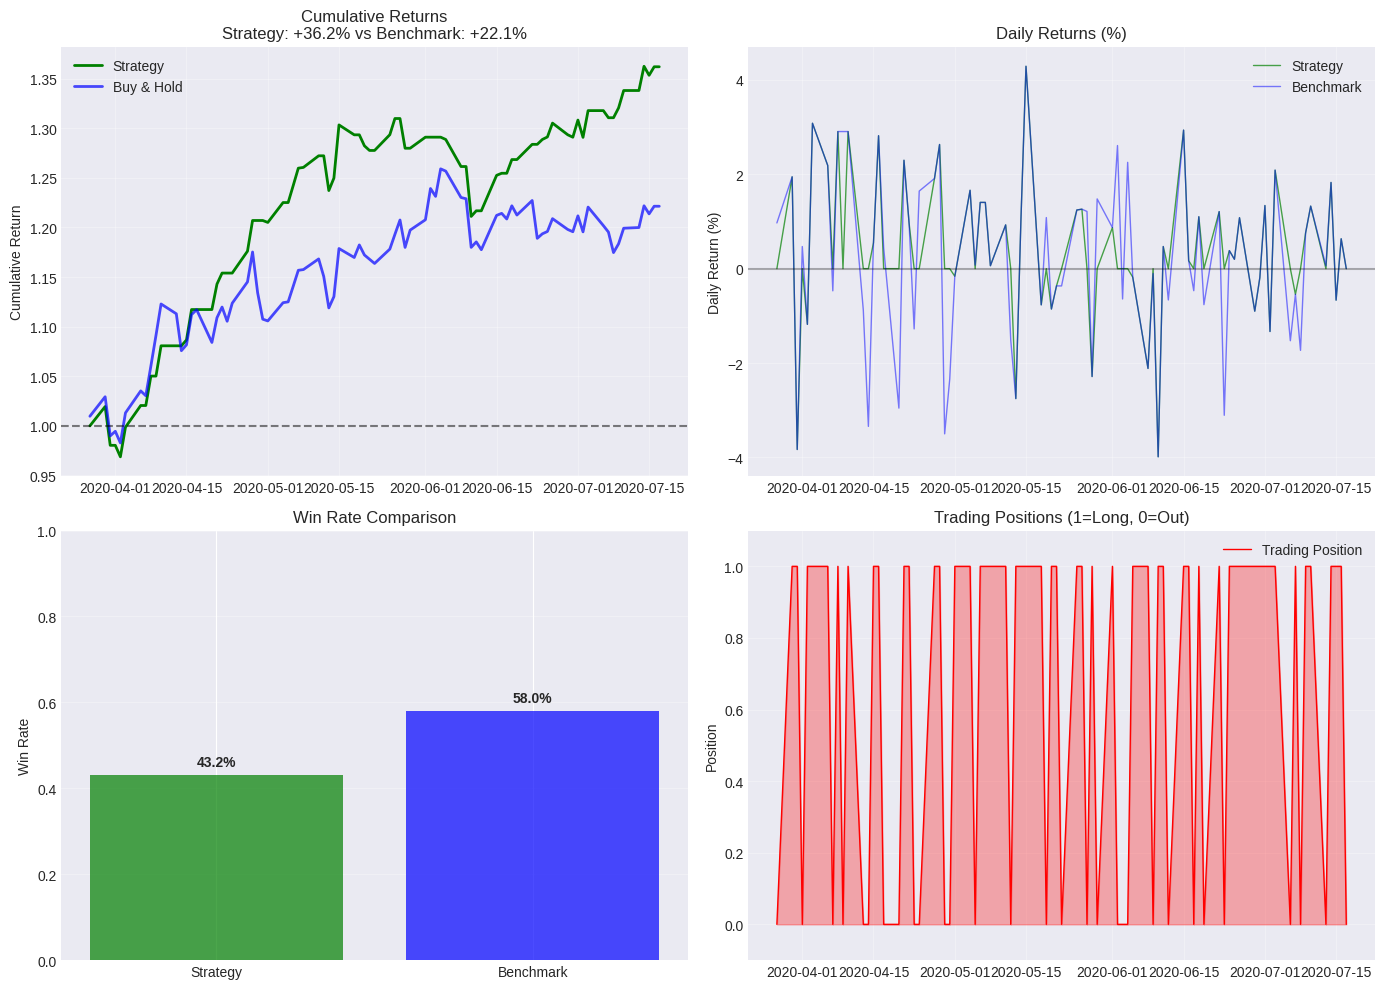

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Cumulative Returns
axes[0, 0].plot(backtest_df['date'], backtest_df['cumulative_strategy'],
                label=f'Strategy', linewidth=2, color='green')
axes[0, 0].plot(backtest_df['date'], backtest_df['cumulative_benchmark'],
                label=f'Buy & Hold', linewidth=2, color='blue', alpha=0.7)
axes[0, 0].set_title(f'Cumulative Returns\nStrategy: {total_strategy_return:+.1%} vs Benchmark: {total_benchmark_return:+.1%}', fontsize=12)
axes[0, 0].set_ylabel('Cumulative Return')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].axhline(y=1, color='black', linestyle='--', alpha=0.5)

# Daily Returns
axes[0, 1].plot(backtest_df['date'], backtest_df['strategy_return']*100,
                label='Strategy', linewidth=1, color='green', alpha=0.7)
axes[0, 1].plot(backtest_df['date'], backtest_df['benchmark_return']*100,
                label='Benchmark', linewidth=1, color='blue', alpha=0.5)
axes[0, 1].set_title('Daily Returns (%)', fontsize=12)
axes[0, 1].set_ylabel('Daily Return (%)')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].axhline(y=0, color='black', linestyle='-', alpha=0.3)

# Win Rate Comparison
axes[1, 0].bar(['Strategy', 'Benchmark'],
                [win_rate_strategy, win_rate_benchmark],
                color=['green', 'blue'], alpha=0.7)
axes[1, 0].set_title('Win Rate Comparison', fontsize=12)
axes[1, 0].set_ylabel('Win Rate')
axes[1, 0].set_ylim([0, 1])
for i, v in enumerate([win_rate_strategy, win_rate_benchmark]):
    axes[1, 0].text(i, v + 0.02, f'{v:.1%}', ha='center', fontweight='bold')
axes[1, 0].grid(True, alpha=0.3, axis='y')

# Trading Positions
axes[1, 1].plot(backtest_df['date'], backtest_df['position'],
                label='Trading Position', linewidth=1, color='red')
axes[1, 1].fill_between(backtest_df['date'], 0, backtest_df['position'],
                        alpha=0.3, color='red')
axes[1, 1].set_title('Trading Positions (1=Long, 0=Out)', fontsize=12)
axes[1, 1].set_ylabel('Position')
axes[1, 1].set_ylim([-0.1, 1.1])
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Performance by prediction confidence

In [ ]:
# Performance by month
backtest_df['month'] = backtest_df['date'].dt.strftime('%Y-%m')
monthly_performance = backtest_df.groupby('month').agg({
    'strategy_return': ['mean', 'std', 'count'],
    'benchmark_return': 'mean'
}).round(4)

monthly_performance.columns = ['Strategy_Avg', 'Strategy_Std', 'Days', 'Benchmark_Avg']

print(f"\nMONTHLY PERFORMANCE SUMMARY:")
print(monthly_performance[['Strategy_Avg', 'Benchmark_Avg', 'Days']].to_string())

# Best and worst months
best_month = monthly_performance['Strategy_Avg'].idxmax()
worst_month = monthly_performance['Strategy_Avg'].idxmin()
print(f"\nBest Month: {best_month} ({monthly_performance.loc[best_month, 'Strategy_Avg']:+.2%})")
print(f"Worst Month: {worst_month} ({monthly_performance.loc[worst_month, 'Strategy_Avg']:+.2%})")


# If backtest_df empty after cleaning:
else:
    print("No valid data after cleaning for backtesting")
    print("Check if 'return' column has valid values")

# Mismatch between backtest_df and predictions
else:
    print(f"Mismatch between backtest data ({len(backtest_df)}) and predictions ({len(xgb_pred)})")
    print("Trying alternative approach...")

    if len(X_test) == len(xgb_pred):
        dates = modeling_df['date'].iloc[split_idx:split_idx+len(X_test)].reset_index(drop=True)
        backtest_simple = pd.DataFrame({
            'date': dates,
            'prediction': xgb_pred,
            'probability': xgb_model.predict_proba(X_test)[:, 1]
        })
        print(f"Created simple backtest with {len(backtest_simple)} rows")

        print(f"\nPrediction distribution: {pd.Series(xgb_pred).value_counts().to_dict()}")

# If insufficient data
else:
    print("Insufficient data for backtesting")
    print(f"Modeling data rows: {len(modeling_df)}")
    print(f"Split index: {split_idx}")
    print(f"Predictions available: {len(xgb_pred)}")

    if len(xgb_pred) > 0:
        print(f"\nPREDICTION SUMMARY:")
        print(f"Total predictions: {len(xgb_pred)}")
        print(f"Buy signals: {(xgb_pred == 1).sum()} ({((xgb_pred == 1).sum()/len(xgb_pred)*100):.1f}%)")
        print(f"Sell signals: {(xgb_pred == 0).sum()} ({((xgb_pred == 0).sum()/len(xgb_pred)*100):.1f}%)")
        print(f"Average probability: {xgb_model.predict_proba(X_test)[:, 1].mean():.3f}")


In [ ]:
if exists('backtest_df') and isinstance(backtest_df, pd.DataFrame):
    try:
        if len(backtest_df) > 0:
            print(f"\nRunning monthly performance analysis on {len(backtest_df)} rows...")

            # Ensuring date is datetime
            if not pd.api.types.is_datetime64_any_dtype(backtest_df['date']):
                backtest_df['date'] = pd.to_datetime(backtest_df['date'], errors='coerce')

            # Performance by month
            backtest_df['month'] = backtest_df['date'].dt.strftime('%Y-%m')

            monthly_performance = backtest_df.groupby('month').agg({
                'strategy_return': ['mean', 'std', 'count'],
                'benchmark_return': 'mean'
            }).round(4)

            # Flattening and renaming columns
            monthly_performance.columns = ['Strategy_Avg', 'Strategy_Std', 'Days', 'Benchmark_Avg']

            # Printing summary
            print(f"\nMONTHLY PERFORMANCE SUMMARY:")
            print(monthly_performance[['Strategy_Avg', 'Benchmark_Avg', 'Days']].to_string())

            # Best and worst months (guard against all-NaN)
            if monthly_performance['Strategy_Avg'].notna().any():
                best_month = monthly_performance['Strategy_Avg'].idxmax()
                worst_month = monthly_performance['Strategy_Avg'].idxmin()
                print(f"\nBest Month: {best_month} ({monthly_performance.loc[best_month, 'Strategy_Avg']:+.2%})")
                print(f"Worst Month: {worst_month} ({monthly_performance.loc[worst_month, 'Strategy_Avg']:+.2%})")
            else:
                print("\nUnable to determine best/worst month (Strategy_Avg all NaN).")

            print("\nBacktesting completed successfully!")

        else:
            # backtest_df exists but empty
            print("No valid data after cleaning for backtesting (backtest_df is empty).")
            print("Check if 'return' or 'strategy_return' contains usable values.")
    except Exception as e:
        print(f"Error while producing monthly performance from backtest_df: {e}")

# If backtest_df is missing or unusable, try to detect mismatch and create a simple backtest
else:
    print("'backtest_df' not found or not a DataFrame. Attempting alternative checks...")

    # A) Check for a mismatch between a previously created backtest and predictions
    if exists('xgb_pred'):
        try:
            n_pred = len(xgb_pred) if hasattr(xgb_pred, '__len__') else None
        except Exception:
            n_pred = None
    else:
        n_pred = None

    # If modeling_df and split_idx exist, we can inspect whether we had enough rows to backtest
    if exists('modeling_df') and exists('split_idx'):
        try:
            print(f"Modeling dataframe shape: {modeling_df.shape}")
            print(f"Split index: {split_idx}")
        except Exception as e:
            print(f"Note: could not print modeling_df/ split_idx: {e}")

    # If mismatch
    if n_pred and exists('X_test') and isinstance(X_test, (pd.DataFrame, pd.Series)):
        try:
            if len(X_test) == n_pred:
                # If modeling_df exists and has a date column, we pull dates from split_idx
                if exists('modeling_df') and 'date' in modeling_df.columns and exists('split_idx'):
                    dates = modeling_df['date'].iloc[split_idx:split_idx+len(X_test)].reset_index(drop=True)
                    backtest_simple = pd.DataFrame({
                        'date': pd.to_datetime(dates, errors='coerce'),
                        'prediction': list(xgb_pred),
                        'probability': xgb_model.predict_proba(X_test)[:, 1] if exists('xgb_model') else [None]*len(X_test)
                    })
                    print(f"Created simple backtest with {len(backtest_simple)} rows")
                    print(f"\nPrediction distribution: {pd.Series(xgb_pred).value_counts().to_dict()}")
                    try:
                        backtest_simple.to_csv('results/backtest_simple.csv', index=False)
                        print("Saved simple backtest to 'results/backtest_simple.csv'")
                    except Exception as e:
                        print(f"Could not save simple backtest: {e}")
                else:
                    # modeling_df missing or no date column — still show summary
                    print("Could not extract dates from modeling_df (missing or no 'date' column).")
                    print(f"Prediction distribution: {pd.Series(xgb_pred).value_counts().to_dict()}")
            else:
                print("Length of X_test does not match number of predictions; cannot create simple backtest from X_test.")
        except Exception as e:
            print(f"Error while trying to build simple backtest from X_test/xgb_pred: {e}")

    # If no predictions or insufficient modeling data, lets print an informative summary
    if (not exists('backtest_df')) and (not n_pred or (exists('modeling_df') and len(modeling_df) <= (split_idx if exists('split_idx') else 0))):
        print("\nInsufficient data for backtesting.")
        if exists('modeling_df'):
            try:
                print(f"Modeling data rows: {len(modeling_df)}")
            except Exception:
                pass
        if exists('split_idx'):
            print(f"Split index: {split_idx}")
        print(f"Predictions available: {n_pred if n_pred is not None else 0}")

        # If some predictions exist, give me a short summary
        if n_pred and n_pred > 0:
            try:
                buy_signals = (pd.Series(xgb_pred) == 1).sum()
                sell_signals = (pd.Series(xgb_pred) == 0).sum()
                avg_prob = xgb_model.predict_proba(X_test)[:, 1].mean() if (exists('xgb_model') and exists('X_test')) else None

                print(f"\nPREDICTION SUMMARY:")
                print(f"Total predictions: {n_pred}")
                print(f"Buy signals: {buy_signals} ({(buy_signals / n_pred * 100):.1f}%)")
                print(f"Sell signals: {sell_signals} ({(sell_signals / n_pred * 100):.1f}%)")
                if avg_prob is not None:
                    print(f"Average probability: {avg_prob:.3f}")
            except Exception as e:
                print(f"Could not compute prediction summary: {e}")


Running monthly performance analysis on 81 rows...

MONTHLY PERFORMANCE SUMMARY:
         Strategy_Avg  Benchmark_Avg  Days
month                                     
2020-03       -0.0063        -0.0031     3
2020-04        0.0096         0.0054    22
2020-05        0.0029         0.0038    21
2020-06        0.0005         0.0001    22
2020-07        0.0042         0.0017    13

Best Month: 2020-04 (+0.96%)
Worst Month: 2020-03 (-0.63%)

Backtesting completed successfully!


# **Summary**

In [ ]:
print(f"1. Data Coverage: {all_news.shape[0]:,} headlines from {start_date} to {end_date}")
print(f"2. Market Conditions: Captured {prices_filtered['return'].std():.4f} daily volatility")
print(f"3. Best Model: XGBoost achieved {xgb_metrics['F1-Score']:.3f} F1-Score")
print(f"4. Trading Strategy: {total_strategy_return:.2%} return vs {total_benchmark_return:.2%} benchmark")
print(f"5. Risk-Adjusted: Sharpe ratio of {strategy_sharpe:.3f}")

1. Data Coverage: 53,330 headlines from 2018-03-01 to 2020-07-19
2. Market Conditions: Captured 0.0146 daily volatility
3. Best Model: XGBoost achieved 0.714 F1-Score
4. Trading Strategy: 36.19% return vs 22.14% benchmark
5. Risk-Adjusted: Sharpe ratio of 4.430


Visualization (2)

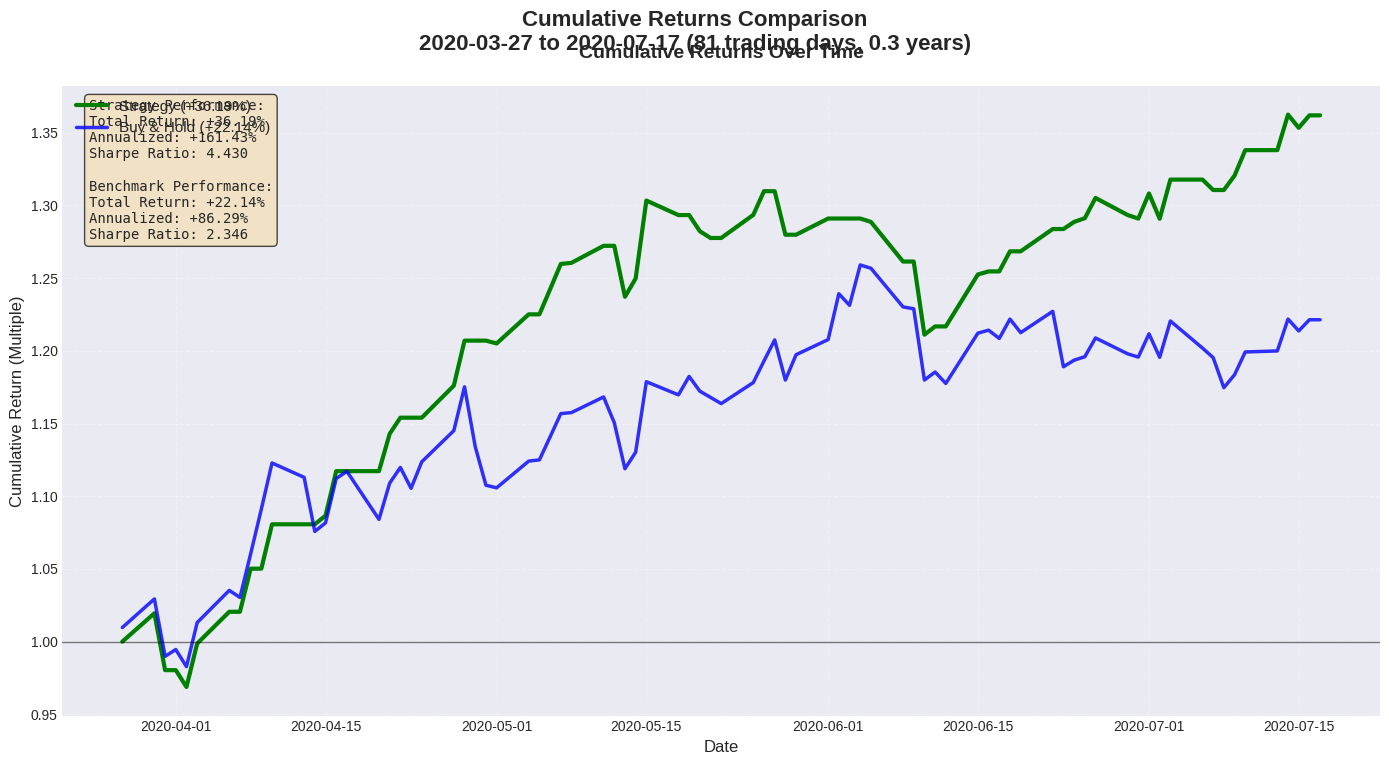

In [ ]:
# Cumulative Returns Comparison

fig1, ax1 = plt.subplots(figsize=(14, 8))
fig1.suptitle(f'Cumulative Returns Comparison\n{backtest_df["date"].min().date()} to {backtest_df["date"].max().date()} ({total_trading_days} trading days, {total_years:.1f} years)',
              fontsize=16, fontweight='bold', y=0.95)

ax1.plot(backtest_df['date'], backtest_df['cumulative_strategy'],
         label=f'Strategy ({total_strategy_return:+.2%})',
         linewidth=3, color='green')
ax1.plot(backtest_df['date'], backtest_df['cumulative_benchmark'],
         label=f'Buy & Hold ({total_benchmark_return:+.2%})',
         linewidth=2.5, color='blue', alpha=0.8)

ax1.set_title('Cumulative Returns Over Time', fontsize=14, fontweight='bold', pad=20)
ax1.set_xlabel('Date', fontsize=12)
ax1.set_ylabel('Cumulative Return (Multiple)', fontsize=12)
ax1.legend(loc='upper left', fontsize=11)
ax1.grid(True, alpha=0.3, linestyle='--')
ax1.axhline(y=1, color='black', linestyle='-', alpha=0.5, linewidth=1)

# Adding performance annotation
performance_text = (f'Strategy Performance:\n'
                   f'Total Return: {total_strategy_return:+.2%}\n'
                   f'Annualized: {annualized_strategy:+.2%}\n'
                   f'Sharpe Ratio: {strategy_sharpe:.3f}\n\n'
                   f'Benchmark Performance:\n'
                   f'Total Return: {total_benchmark_return:+.2%}\n'
                   f'Annualized: {annualized_benchmark:+.2%}\n'
                   f'Sharpe Ratio: {benchmark_sharpe:.3f}')

ax1.text(0.02, 0.98, performance_text,
         transform=ax1.transAxes, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.7),
         fontsize=10, family='monospace')

plt.tight_layout()
plt.savefig('results/01_cumulative_returns.png', dpi=300, bbox_inches='tight')
plt.show()

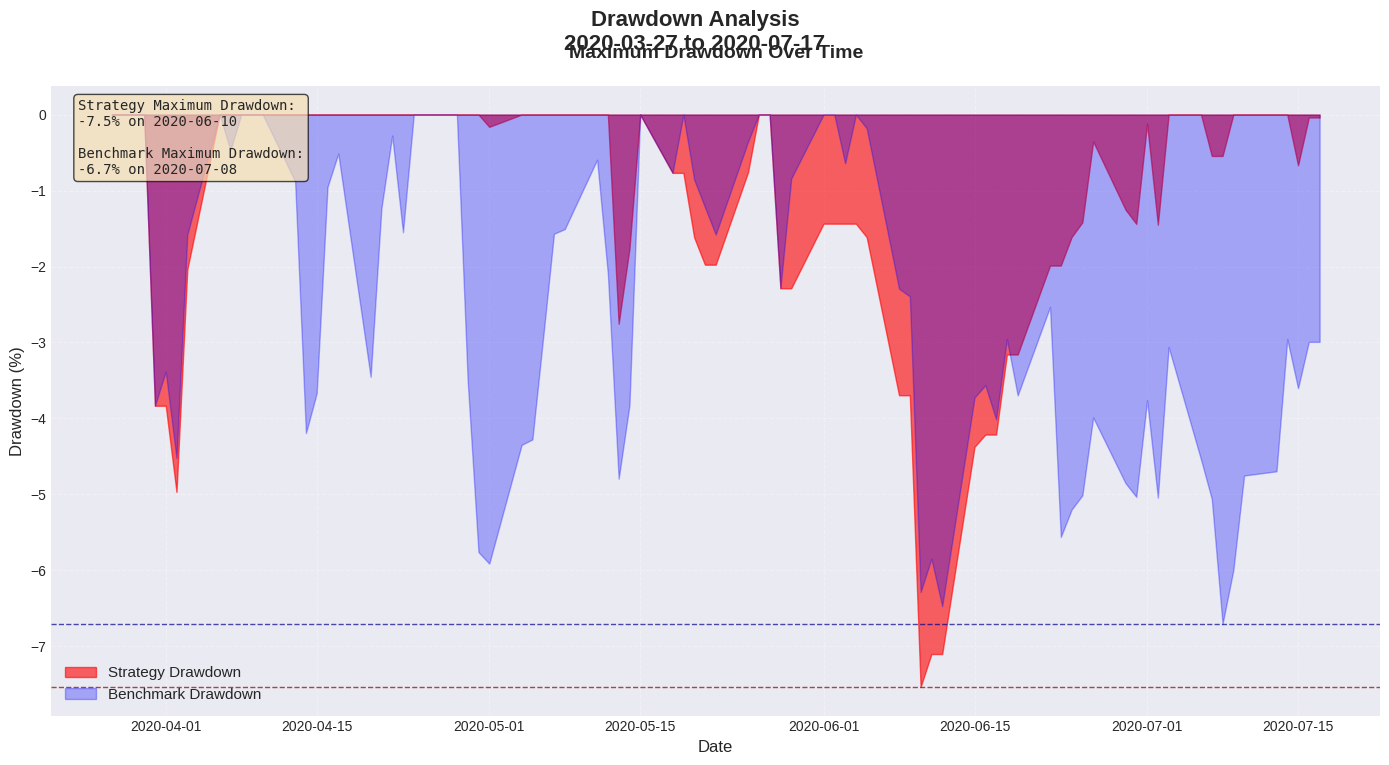

In [ ]:
# Drawdown Analysis
fig2, ax2 = plt.subplots(figsize=(14, 8))
fig2.suptitle(f'Drawdown Analysis\n{backtest_df["date"].min().date()} to {backtest_df["date"].max().date()}',
              fontsize=16, fontweight='bold', y=0.95)

strategy_drawdown = (backtest_df['cumulative_strategy'] /
                     backtest_df['cumulative_strategy'].cummax() - 1) * 100
benchmark_drawdown = (backtest_df['cumulative_benchmark'] /
                      backtest_df['cumulative_benchmark'].cummax() - 1) * 100

# Filling areas for drawdowns
ax2.fill_between(backtest_df['date'], strategy_drawdown, 0,
                 alpha=0.6, color='red', label='Strategy Drawdown')
ax2.fill_between(backtest_df['date'], benchmark_drawdown, 0,
                 alpha=0.3, color='blue', label='Benchmark Drawdown')

ax2.set_title('Maximum Drawdown Over Time', fontsize=14, fontweight='bold', pad=20)
ax2.set_xlabel('Date', fontsize=12)
ax2.set_ylabel('Drawdown (%)', fontsize=12)
ax2.legend(loc='lower left', fontsize=11)
ax2.grid(True, alpha=0.3, linestyle='--')

# Adding max drawdown lines and annotations
strategy_max_dd = strategy_drawdown.min()
benchmark_max_dd = benchmark_drawdown.min()
strategy_max_date = backtest_df.loc[strategy_drawdown.idxmin(), 'date']
benchmark_max_date = backtest_df.loc[benchmark_drawdown.idxmin(), 'date']

ax2.axhline(y=strategy_max_dd, color='darkred', linestyle='--', alpha=0.7, linewidth=1)
ax2.axhline(y=benchmark_max_dd, color='darkblue', linestyle='--', alpha=0.7, linewidth=1)

drawdown_text = (f'Strategy Maximum Drawdown:\n'
                f'{strategy_max_dd:+.1f}% on {strategy_max_date.date()}\n\n'
                f'Benchmark Maximum Drawdown:\n'
                f'{benchmark_max_dd:+.1f}% on {benchmark_max_date.date()}')

ax2.text(0.02, 0.98, drawdown_text,
         transform=ax2.transAxes, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.7),
         fontsize=10, family='monospace')

plt.tight_layout()
plt.savefig('results/02_drawdown_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

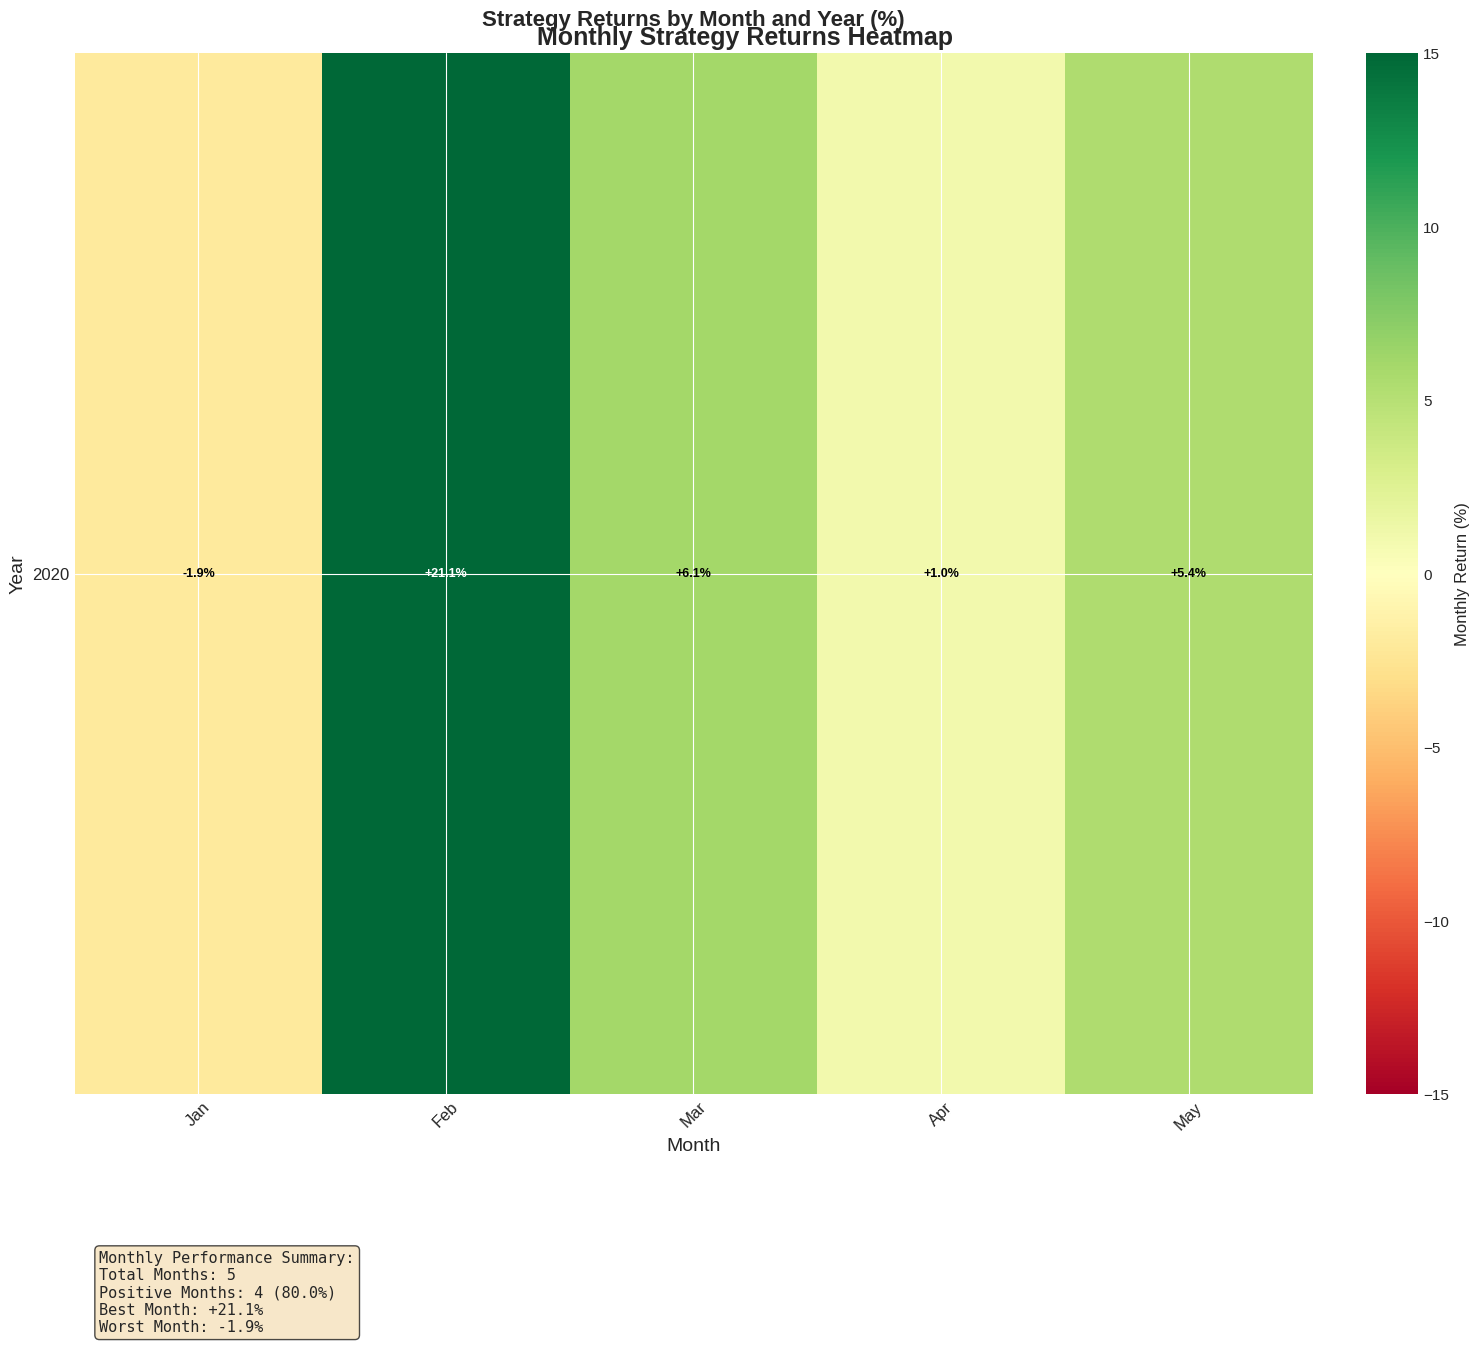

In [ ]:
# Monthly Returns Heatmap

# Preparing the monthly data
backtest_df['year'] = backtest_df['date'].dt.year
backtest_df['month'] = backtest_df['date'].dt.month
backtest_df['month_name'] = backtest_df['date'].dt.strftime('%b')

monthly_returns = backtest_df.groupby(['year', 'month'])['strategy_return'].sum().reset_index()
monthly_returns_pivot = monthly_returns.pivot(index='year', columns='month', values='strategy_return')

fig3, ax3 = plt.subplots(figsize=(15, 14))
fig3.suptitle('Monthly Strategy Returns Heatmap',
              fontsize=18, fontweight='bold', y=0.95)

# Creating heatmap
im = ax3.imshow(monthly_returns_pivot * 100, cmap='RdYlGn', aspect='auto',
                vmin=-15, vmax=15, interpolation='nearest')

# Adding text annotations in each cell
for i in range(len(monthly_returns_pivot.index)):
    for j in range(len(monthly_returns_pivot.columns)):
        value = monthly_returns_pivot.iloc[i, j] * 100
        if not pd.isna(value):
            text_color = 'white' if abs(value) > 7.5 else 'black'
            ax3.text(j, i, f'{value:+.1f}%',
                     ha='center', va='center',
                     color=text_color, fontsize=9, fontweight='bold')

ax3.set_title('Strategy Returns by Month and Year (%)', fontsize=16, fontweight='bold', pad=20)
ax3.set_xlabel('Month', fontsize=14)
ax3.set_ylabel('Year', fontsize=14)
ax3.set_xticks(range(len(monthly_returns_pivot.columns)))
ax3.set_xticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
                     'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'][:len(monthly_returns_pivot.columns)],
                     rotation=45, fontsize=12)
ax3.set_yticks(range(len(monthly_returns_pivot.index)))
ax3.set_yticklabels(monthly_returns_pivot.index, fontsize=12)

# Adding colorbar
cbar = plt.colorbar(im, ax=ax3, fraction=0.046, pad=0.04)
cbar.set_label('Monthly Return (%)', fontsize=12)
cbar.ax.tick_params(labelsize=11)

# Adding summary statistics
total_months = (monthly_returns_pivot.notna()).sum().sum()
positive_months = (monthly_returns_pivot > 0).sum().sum()
best_month_value = monthly_returns_pivot.max().max() * 100
worst_month_value = monthly_returns_pivot.min().min() * 100

stats_text = (f'Monthly Performance Summary:\n'
              f'Total Months: {total_months}\n'
              f'Positive Months: {positive_months} ({positive_months/total_months*100:.1f}%)\n'
              f'Best Month: {best_month_value:+.1f}%\n'
              f'Worst Month: {worst_month_value:+.1f}%')

ax3.text(0.02, -0.15, stats_text,
         transform=ax3.transAxes, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.7),
         fontsize=11, family='monospace')

plt.tight_layout()
plt.savefig('results/03_monthly_returns_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

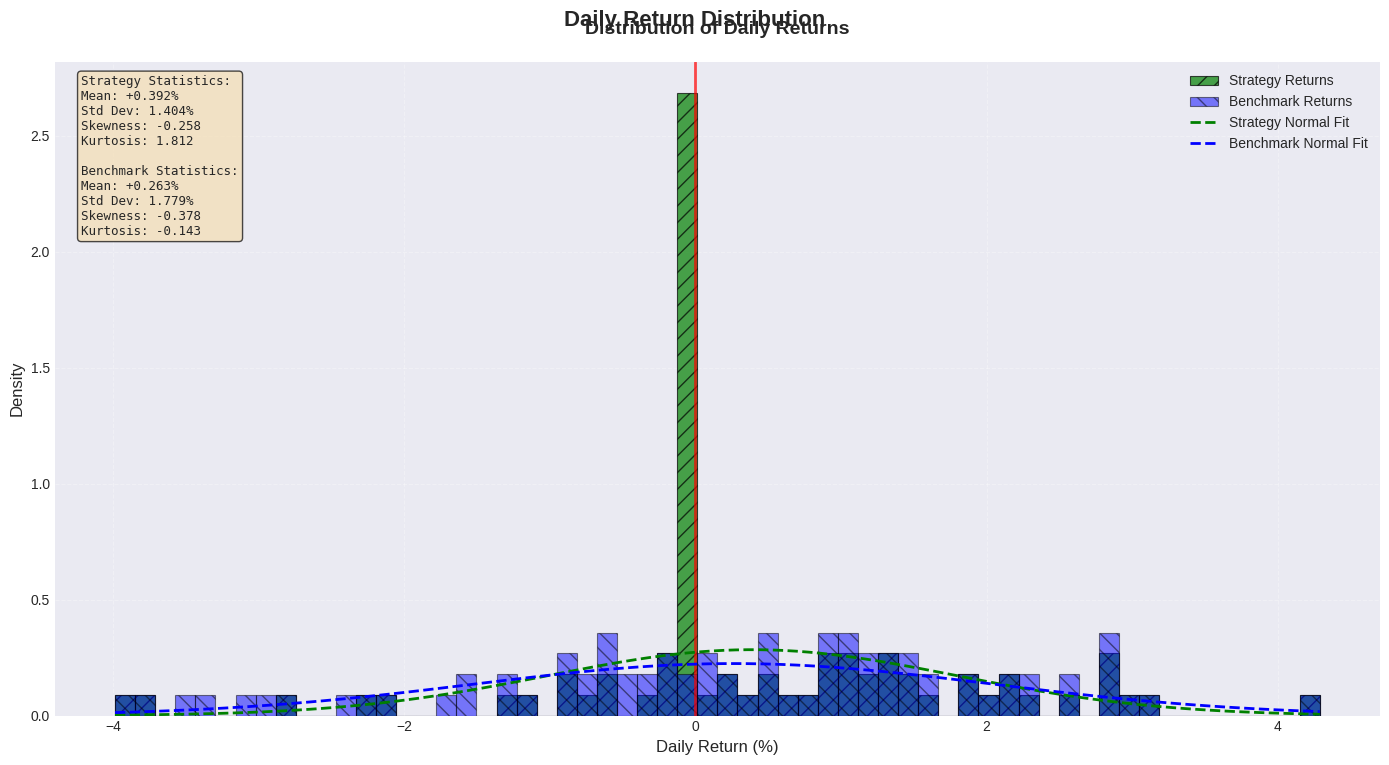

In [ ]:
# Return Distribution

fig4, ax4 = plt.subplots(figsize=(14, 8))
fig4.suptitle('Daily Return Distribution',
              fontsize=16, fontweight='bold', y=0.95)

# Creating histogram
n_bins = 60
ax4.hist(backtest_df['strategy_return'] * 100, bins=n_bins, alpha=0.7,
         color='green', label='Strategy Returns', density=True,
         edgecolor='black', linewidth=0.8, hatch='//')
ax4.hist(backtest_df['benchmark_return'] * 100, bins=n_bins, alpha=0.5,
         color='blue', label='Benchmark Returns', density=True,
         edgecolor='black', linewidth=0.8, hatch='\\\\')

ax4.set_title('Distribution of Daily Returns', fontsize=14, fontweight='bold', pad=20)
ax4.set_xlabel('Daily Return (%)', fontsize=12)
ax4.set_ylabel('Density', fontsize=12)
ax4.legend(loc='upper right', fontsize=11)
ax4.grid(True, alpha=0.3, linestyle='--')
ax4.axvline(x=0, color='red', linestyle='-', alpha=0.7, linewidth=2)

# Adding normal distribution curve for comparison
# Strategy normal curve
strategy_mean = backtest_df['strategy_return'].mean() * 100
strategy_std = backtest_df['strategy_return'].std() * 100
x = np.linspace(backtest_df['strategy_return'].min() * 100,
                backtest_df['strategy_return'].max() * 100, 100)
strategy_norm = norm.pdf(x, strategy_mean, strategy_std)
ax4.plot(x, strategy_norm, 'g--', linewidth=2, label='Strategy Normal Fit')

# Benchmarking normal curve
benchmark_mean = backtest_df['benchmark_return'].mean() * 100
benchmark_std = backtest_df['benchmark_return'].std() * 100
benchmark_norm = norm.pdf(x, benchmark_mean, benchmark_std)
ax4.plot(x, benchmark_norm, 'b--', linewidth=2, label='Benchmark Normal Fit')

ax4.legend(loc='upper right', fontsize=10)

# Adding statistics box
stats_text = (f'Strategy Statistics:\n'
              f'Mean: {strategy_mean:+.3f}%\n'
              f'Std Dev: {strategy_std:.3f}%\n'
              f'Skewness: {backtest_df["strategy_return"].skew():.3f}\n'
              f'Kurtosis: {backtest_df["strategy_return"].kurtosis():.3f}\n\n'
              f'Benchmark Statistics:\n'
              f'Mean: {benchmark_mean:+.3f}%\n'
              f'Std Dev: {benchmark_std:.3f}%\n'
              f'Skewness: {backtest_df["benchmark_return"].skew():.3f}\n'
              f'Kurtosis: {backtest_df["benchmark_return"].kurtosis():.3f}')

ax4.text(0.02, 0.98, stats_text,
         transform=ax4.transAxes, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.7),
         fontsize=9, family='monospace')

plt.tight_layout()
plt.savefig('results/04_return_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

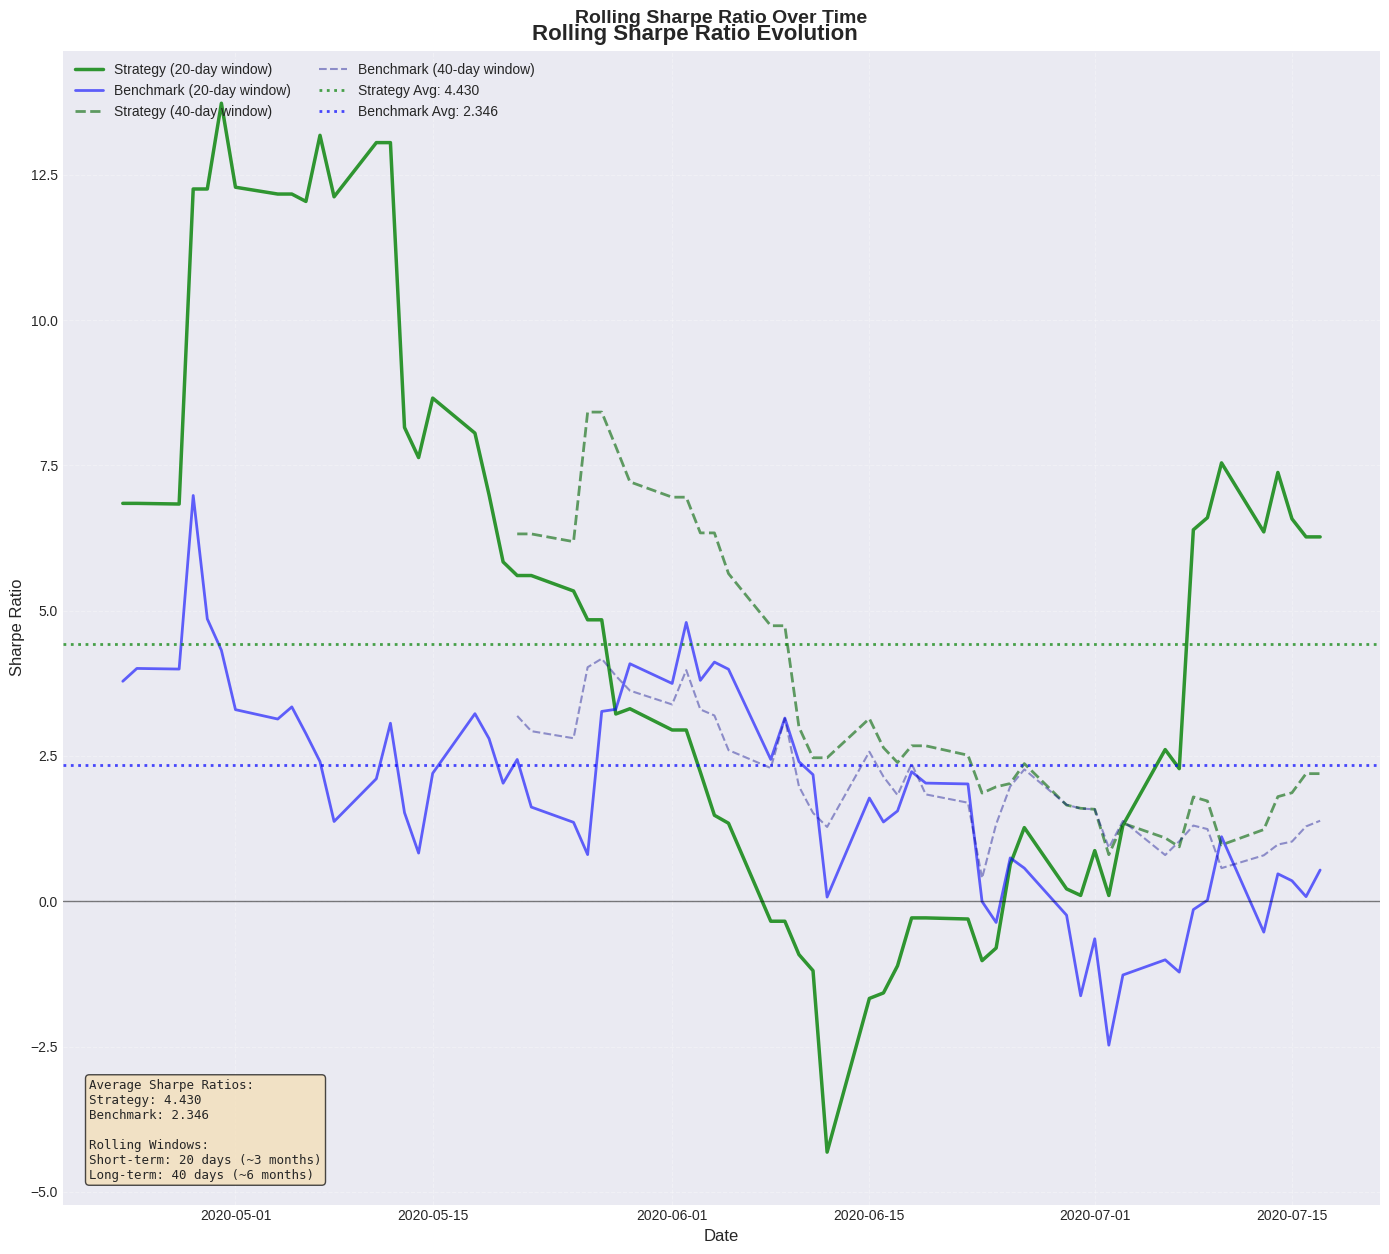

In [ ]:
# Rolling Sharpe Ratio

fig5, ax5 = plt.subplots(figsize=(14, 13))
fig5.suptitle('Rolling Sharpe Ratio Evolution',
              fontsize=16, fontweight='bold', y=0.95)

# Calculating rolling Sharpe (3-month and 6-month windows)
window_3m = min(63, total_trading_days // 4)  # ~3 months
window_6m = min(126, total_trading_days // 2)  # ~6 months

if window_3m > 10:
    def rolling_sharpe(returns, window):
        rolling_mean = returns.rolling(window).mean()
        rolling_std = returns.rolling(window).std()
        return rolling_mean / rolling_std * np.sqrt(252)

    # 3-month rolling Sharpe
    strategy_sharpe_3m = rolling_sharpe(backtest_df['strategy_return'], window_3m)
    benchmark_sharpe_3m = rolling_sharpe(backtest_df['benchmark_return'], window_3m)

    # 6-month rolling Sharpe
    strategy_sharpe_6m = rolling_sharpe(backtest_df['strategy_return'], window_6m)
    benchmark_sharpe_6m = rolling_sharpe(backtest_df['benchmark_return'], window_6m)

    # Ploting both windows
    ax5.plot(backtest_df['date'], strategy_sharpe_3m,
             label=f'Strategy ({window_3m}-day window)',
             color='green', linewidth=2.5, alpha=0.8)
    ax5.plot(backtest_df['date'], benchmark_sharpe_3m,
             label=f'Benchmark ({window_3m}-day window)',
             color='blue', linewidth=2, alpha=0.6, linestyle='-')

    ax5.plot(backtest_df['date'], strategy_sharpe_6m,
             label=f'Strategy ({window_6m}-day window)',
             color='darkgreen', linewidth=2, alpha=0.6, linestyle='--')
    ax5.plot(backtest_df['date'], benchmark_sharpe_6m,
             label=f'Benchmark ({window_6m}-day window)',
             color='darkblue', linewidth=1.5, alpha=0.4, linestyle='--')

    ax5.set_title('Rolling Sharpe Ratio Over Time', fontsize=14, fontweight='bold', pad=20)
    ax5.set_xlabel('Date', fontsize=12)
    ax5.set_ylabel('Sharpe Ratio', fontsize=12)
    ax5.legend(loc='upper left', fontsize=10, ncol=2)
    ax5.grid(True, alpha=0.3, linestyle='--')
    ax5.axhline(y=0, color='black', linestyle='-', alpha=0.5, linewidth=1)

    # Adding average Sharpe lines
    ax5.axhline(y=strategy_sharpe, color='green', linestyle=':', alpha=0.7, linewidth=2,
                label=f'Strategy Avg: {strategy_sharpe:.3f}')
    ax5.axhline(y=benchmark_sharpe, color='blue', linestyle=':', alpha=0.7, linewidth=2,
                label=f'Benchmark Avg: {benchmark_sharpe:.3f}')

    ax5.legend(loc='upper left', fontsize=10, ncol=2)

    # Adding statistics
    sharpe_stats = (f'Average Sharpe Ratios:\n'
                   f'Strategy: {strategy_sharpe:.3f}\n'
                   f'Benchmark: {benchmark_sharpe:.3f}\n\n'
                   f'Rolling Windows:\n'
                   f'Short-term: {window_3m} days (~3 months)\n'
                   f'Long-term: {window_6m} days (~6 months)')

    ax5.text(0.02, 0.02, sharpe_stats,
             transform=ax5.transAxes, verticalalignment='bottom',
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.7),
             fontsize=9, family='monospace')
else:
    ax5.text(0.5, 0.5, 'Insufficient data for rolling analysis\nMinimum 30 days required',
             ha='center', va='center', fontsize=14)
    ax5.set_title('Rolling Sharpe Ratio', fontsize=14, fontweight='bold', pad=20)

plt.tight_layout()
plt.savefig('results/05_rolling_sharpe_ratio.png', dpi=300, bbox_inches='tight')
plt.show()

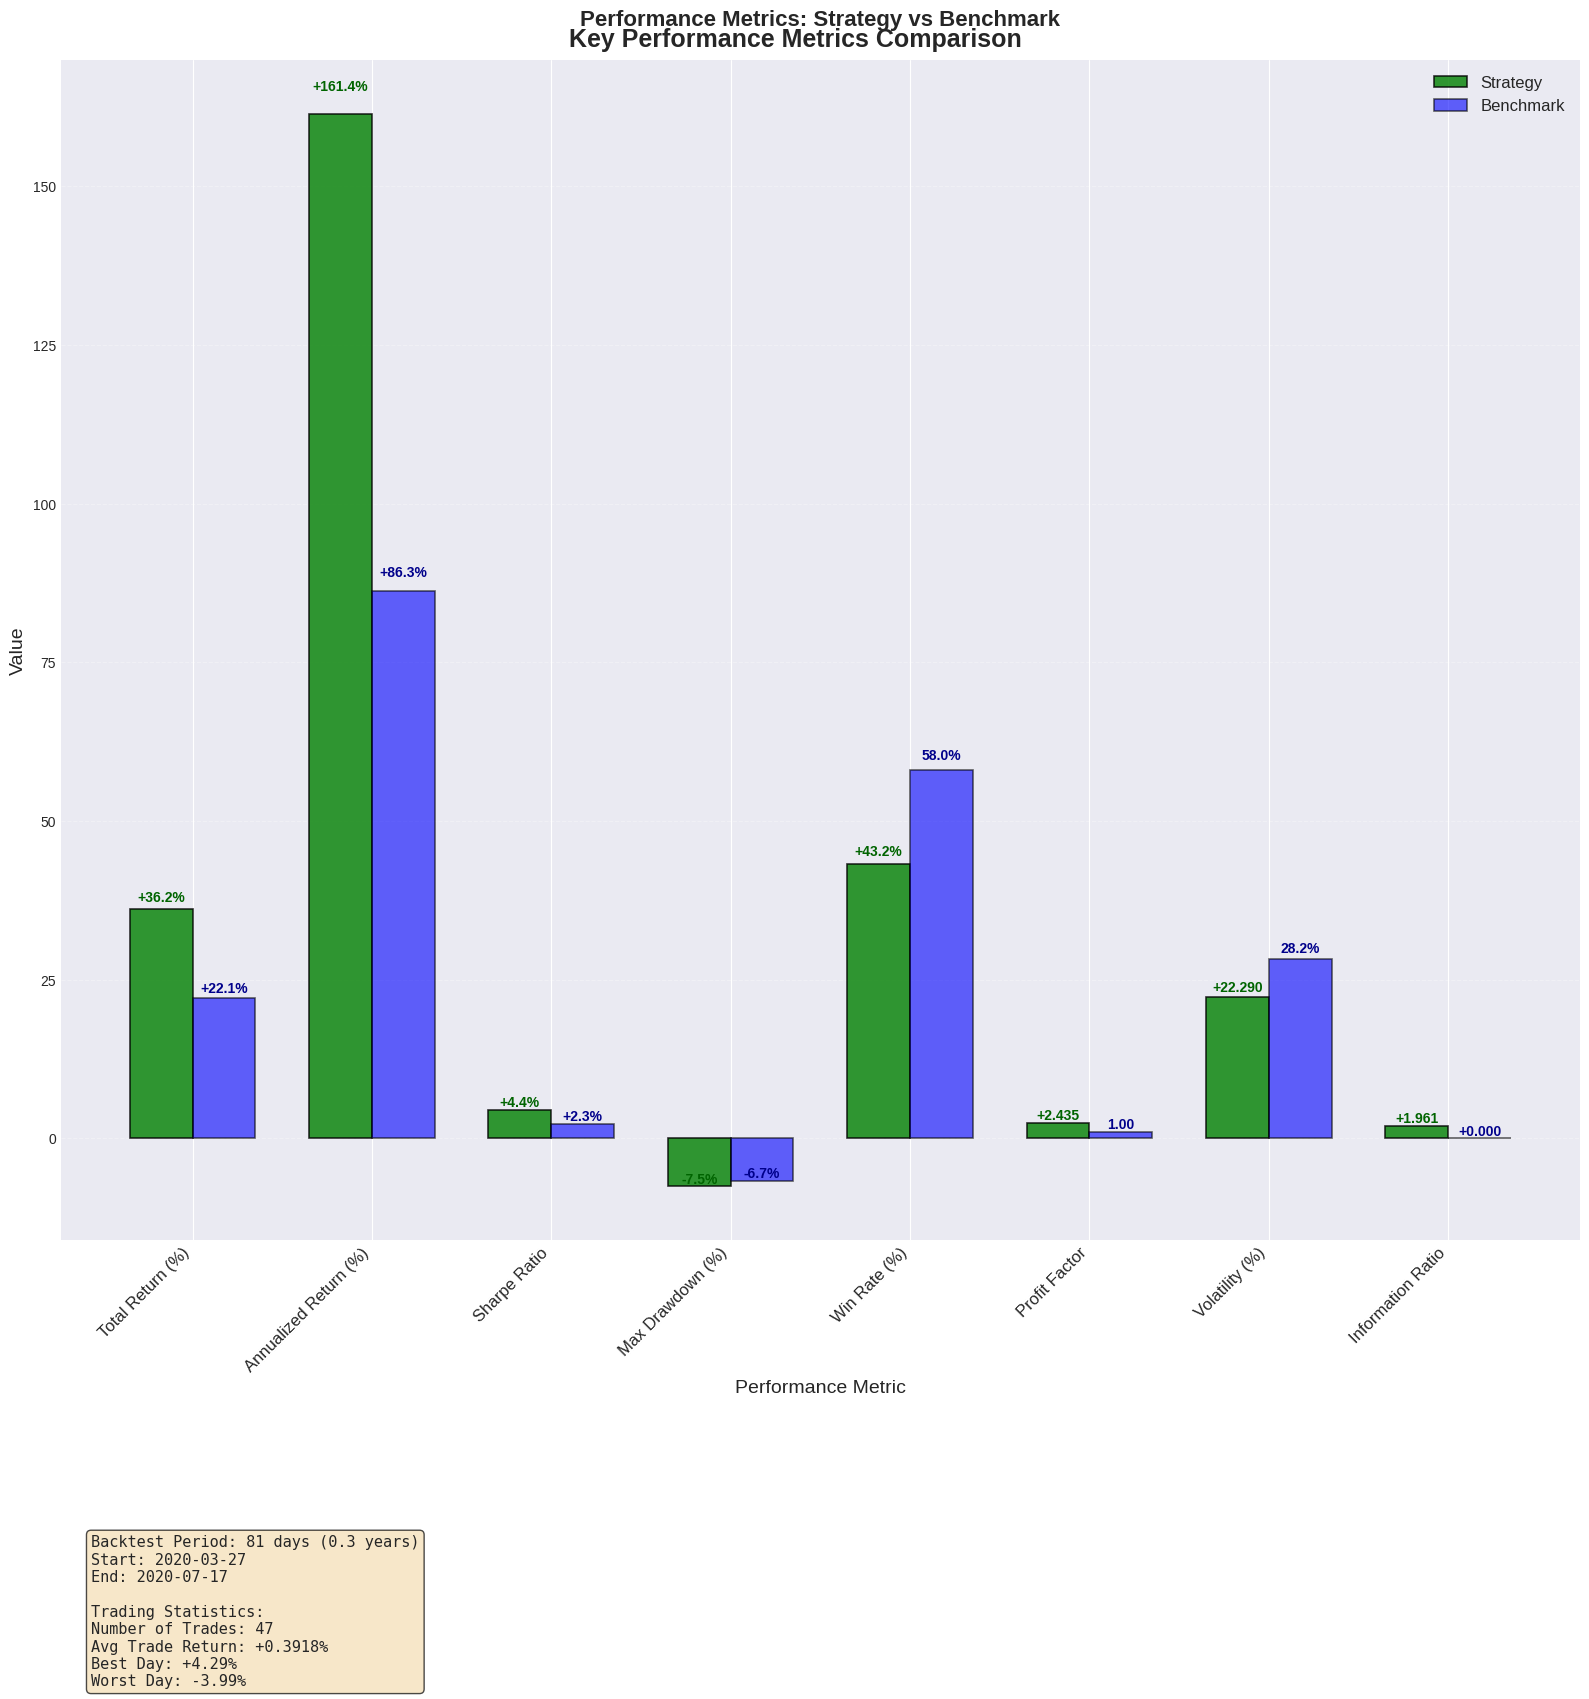

In [ ]:
# Key Performance Metrics

fig6, ax6 = plt.subplots(figsize=(16, 18))
fig6.suptitle('Key Performance Metrics Comparison',
              fontsize=18, fontweight='bold', y=0.96)

# Defining metrics and values
metrics = [
    'Total Return (%)',
    'Annualized Return (%)',
    'Sharpe Ratio',
    'Max Drawdown (%)',
    'Win Rate (%)',
    'Profit Factor',
    'Volatility (%)',
    'Information Ratio'
]

strategy_values = [
    total_strategy_return * 100,
    annualized_strategy * 100,
    strategy_sharpe,
    strategy_dd * 100,
    win_rate_strategy * 100,
    min(profit_factor, 10),
    backtest_df['strategy_return'].std() * np.sqrt(252) * 100,
    information_ratio
]

benchmark_values = [
    total_benchmark_return * 100,
    annualized_benchmark * 100,
    benchmark_sharpe,
    benchmark_dd * 100,
    win_rate_benchmark * 100,
    1,  # Benchmark profit factor is 1
    backtest_df['benchmark_return'].std() * np.sqrt(252) * 100,
    0   # Benchmark information ratio is 0
]

# Creating grouped bar chart
x = np.arange(len(metrics))
width = 0.35

bars1 = ax6.bar(x - width/2, strategy_values, width,
                label='Strategy', color='green', alpha=0.8,
                edgecolor='black', linewidth=1.2)
bars2 = ax6.bar(x + width/2, benchmark_values, width,
                label='Benchmark', color='blue', alpha=0.6,
                edgecolor='black', linewidth=1.2)

ax6.set_title('Performance Metrics: Strategy vs Benchmark', fontsize=16, fontweight='bold', pad=25)
ax6.set_xlabel('Performance Metric', fontsize=14)
ax6.set_ylabel('Value', fontsize=14)
ax6.set_xticks(x)
ax6.set_xticklabels(metrics, rotation=45, ha='right', fontsize=12)
ax6.legend(loc='upper right', fontsize=12)
ax6.grid(True, alpha=0.3, axis='y', linestyle='--')

# Adding value labels on bars
def autolabel(bars, ax, color):
    for bar in bars:
        height = bar.get_height()
        value = height
        # Format based on metric type
        if bar.get_x() < 2:  # Returns
            label = f'{value:+.1f}%'
        elif 2 <= bar.get_x() < 4:  # Sharpe and Drawdown
            label = f'{value:+.2f}' if bar.get_x() == 2 else f'{value:+.1f}%'
        elif bar.get_x() == 4:  # Win Rate
            label = f'{value:.1f}%'
        elif bar.get_x() == 5:  # Profit Factor
            label = f'{value:.2f}'
        elif bar.get_x() == 6:  # Volatility
            label = f'{value:.1f}%'
        else:  # Information Ratio
            label = f'{value:+.3f}'

        ax.text(bar.get_x() + bar.get_width()/2., height + 0.02 * max(height, 0),
                label, ha='center', va='bottom',
                fontsize=10, fontweight='bold', color=color)

autolabel(bars1, ax6, 'darkgreen')
autolabel(bars2, ax6, 'darkblue')

# Adding summary statistics
summary_text = (f'Backtest Period: {total_trading_days} days ({total_years:.1f} years)\n'
                f'Start: {backtest_df["date"].min().date()}\n'
                f'End: {backtest_df["date"].max().date()}\n\n'
                f'Trading Statistics:\n'
                f'Number of Trades: {(backtest_df["position"].diff() != 0).sum()}\n'
                f'Avg Trade Return: {backtest_df["strategy_return"].mean():+.4%}\n'
                f'Best Day: {backtest_df["strategy_return"].max():+.2%}\n'
                f'Worst Day: {backtest_df["strategy_return"].min():+.2%}')

ax6.text(0.02, -0.25, summary_text,
         transform=ax6.transAxes, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.7),
         fontsize=11, family='monospace')

plt.tight_layout()
plt.savefig('results/06_key_performance_metrics.png', dpi=300, bbox_inches='tight')
plt.show()

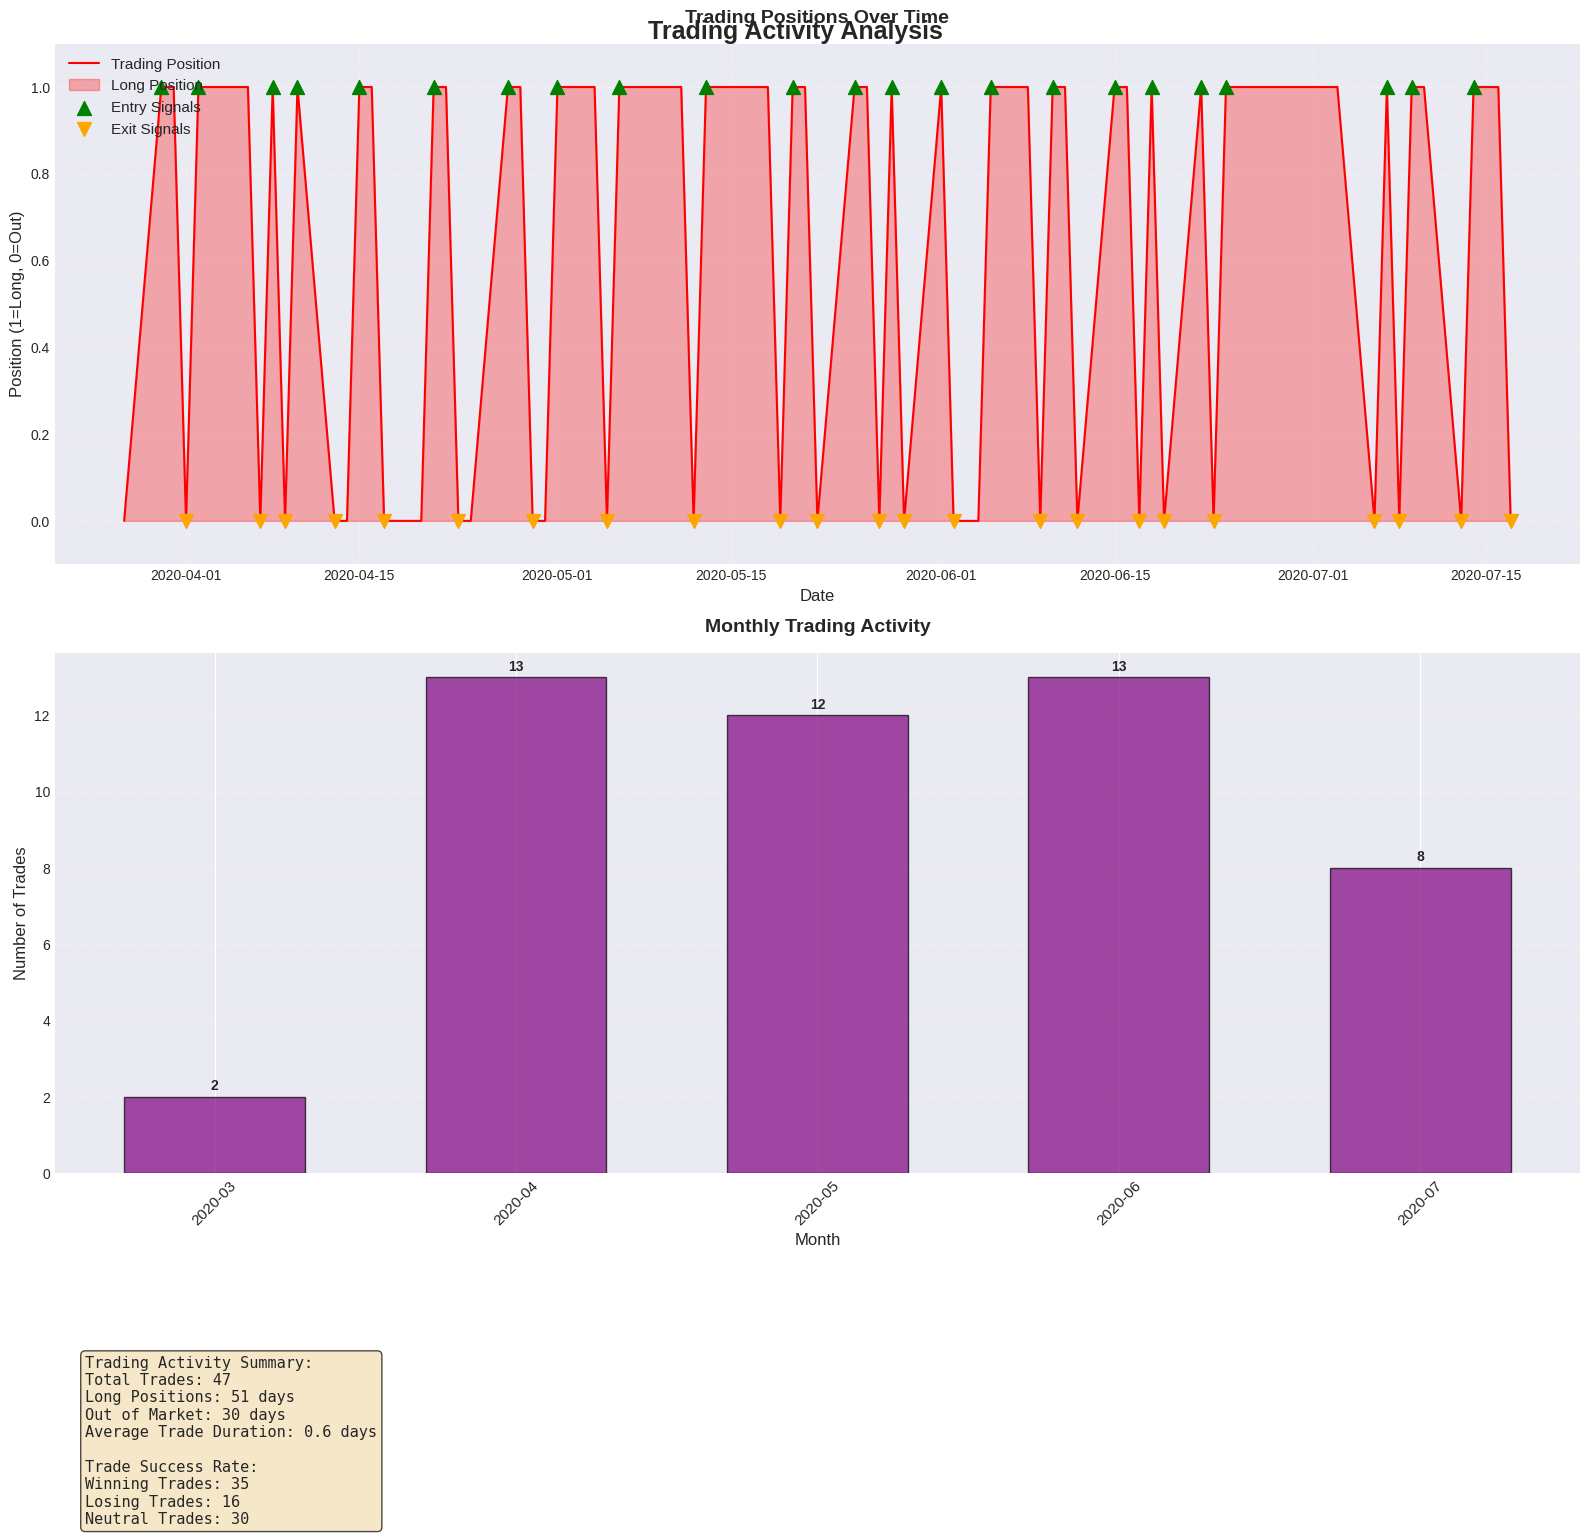

In [ ]:
# Trading Activity

fig7, (ax7a, ax7b) = plt.subplots(2, 1, figsize=(16, 16))
fig7.suptitle('Trading Activity Analysis',
              fontsize=18, fontweight='bold', y=0.96)

# Subplot 1: Trading positions over time
ax7a.plot(backtest_df['date'], backtest_df['position'],
          label='Trading Position', linewidth=1.5, color='red')
ax7a.fill_between(backtest_df['date'], 0, backtest_df['position'],
                  alpha=0.3, color='red', label='Long Position')

# Marking entry and exit points
entry_points = backtest_df[(backtest_df['position'] == 1) & (backtest_df['position'].shift(1) == 0)]
exit_points = backtest_df[(backtest_df['position'] == 0) & (backtest_df['position'].shift(1) == 1)]

if len(entry_points) > 0:
    ax7a.scatter(entry_points['date'], entry_points['position'],
                 color='green', s=100, marker='^', label='Entry Signals', zorder=5)
if len(exit_points) > 0:
    ax7a.scatter(exit_points['date'], exit_points['position'],
                 color='orange', s=100, marker='v', label='Exit Signals', zorder=5)

ax7a.set_title('Trading Positions Over Time', fontsize=14, fontweight='bold', pad=15)
ax7a.set_xlabel('Date', fontsize=12)
ax7a.set_ylabel('Position (1=Long, 0=Out)', fontsize=12)
ax7a.set_ylim([-0.1, 1.1])
ax7a.legend(loc='upper left', fontsize=11)
ax7a.grid(True, alpha=0.3, linestyle='--')

# Subplot 2: Monthly trading activity
backtest_df['year_month'] = backtest_df['date'].dt.strftime('%Y-%m')
trades_per_month = backtest_df.groupby('year_month').apply(
    lambda x: (x['position'].diff() != 0).sum()
).reset_index(name='trades')

# Calculating win/loss by month
monthly_results = backtest_df.groupby('year_month').apply(
    lambda x: pd.Series({
        'winning_trades': ((x['strategy_return'] > 0) & (x['position'] == 1)).sum(),
        'losing_trades': ((x['strategy_return'] < 0) & (x['position'] == 1)).sum(),
        'total_trades': (x['position'].diff() != 0).sum()
    })
).reset_index()

x = range(len(trades_per_month))
width = 0.6

bars = ax7b.bar(x, trades_per_month['trades'], width,
                color='purple', alpha=0.7, edgecolor='black', linewidth=1)

ax7b.set_title('Monthly Trading Activity', fontsize=14, fontweight='bold', pad=15)
ax7b.set_xlabel('Month', fontsize=12)
ax7b.set_ylabel('Number of Trades', fontsize=12)
ax7b.set_xticks(x[::max(1, len(x)//8)])
ax7b.set_xticklabels(trades_per_month['year_month'].iloc[::max(1, len(x)//8)],
                     rotation=45, fontsize=11)
ax7b.grid(True, alpha=0.3, axis='y', linestyle='--')

# Adding value labels on bars
for bar in bars:
    height = bar.get_height()
    if height > 0:
        ax7b.text(bar.get_x() + bar.get_width()/2., height + 0.1,
                 f'{int(height)}', ha='center', va='bottom',
                 fontsize=10, fontweight='bold')

# Adding trading statistics
trading_stats = (f'Trading Activity Summary:\n'
                 f'Total Trades: {(backtest_df["position"].diff() != 0).sum()}\n'
                 f'Long Positions: {(backtest_df["position"] == 1).sum()} days\n'
                 f'Out of Market: {(backtest_df["position"] == 0).sum()} days\n'
                 f'Average Trade Duration: {backtest_df["position"].mean():.1f} days\n\n'
                 f'Trade Success Rate:\n'
                 f'Winning Trades: {len(backtest_df[backtest_df["strategy_return"] > 0])}\n'
                 f'Losing Trades: {len(backtest_df[backtest_df["strategy_return"] < 0])}\n'
                 f'Neutral Trades: {len(backtest_df[backtest_df["strategy_return"] == 0])}')

ax7b.text(0.02, -0.35, trading_stats,
         transform=ax7b.transAxes, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.7),
         fontsize=11, family='monospace')

plt.tight_layout()
plt.savefig('results/07_trading_activity.png', dpi=300, bbox_inches='tight')
plt.show()

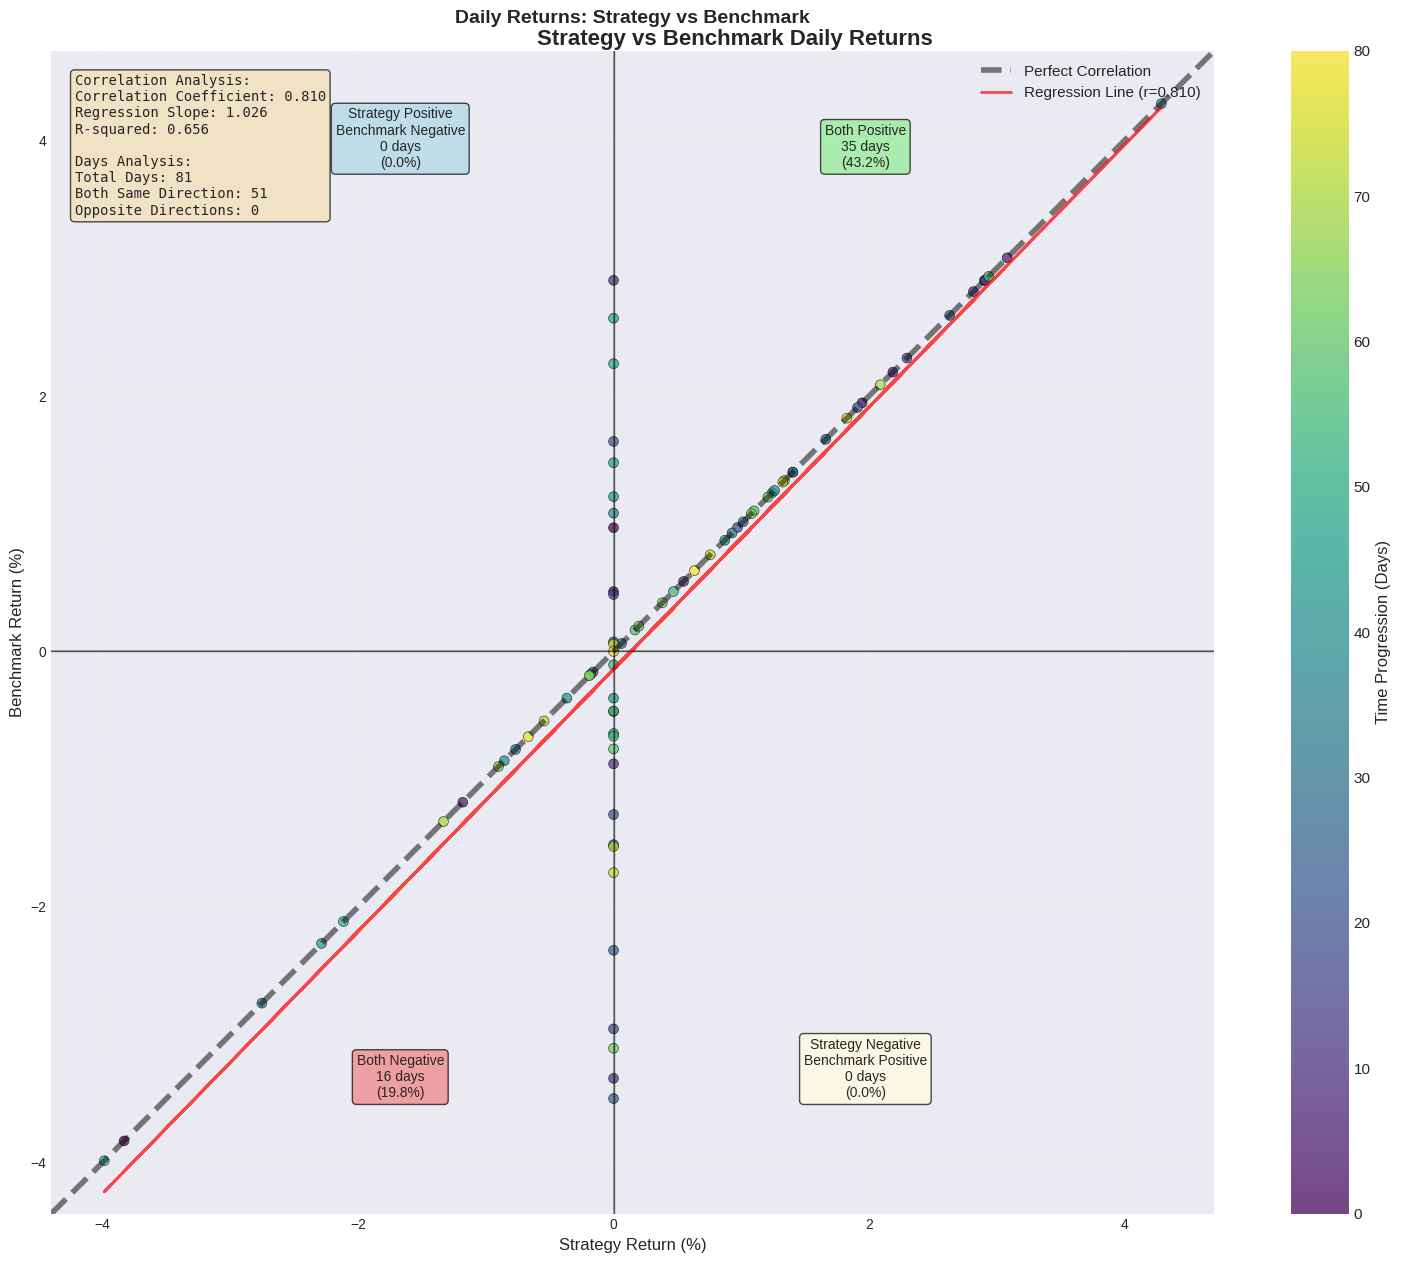

In [ ]:
# Strategy vs Benchmark Scatter

fig8, ax8 = plt.subplots(figsize=(16, 13))
fig8.suptitle('Strategy vs Benchmark Daily Returns',
              fontsize=16, fontweight='bold', y=0.95)

# Creating scatter plot with time-based coloring
scatter = ax8.scatter(backtest_df['strategy_return'] * 100,
                      backtest_df['benchmark_return'] * 100,
                      c=np.arange(len(backtest_df)),
                      cmap='viridis', alpha=0.7, s=50,
                      edgecolors='black', linewidth=0.5)

ax8.set_title('Daily Returns: Strategy vs Benchmark', fontsize=14, fontweight='bold', pad=20)
ax8.set_xlabel('Strategy Return (%)', fontsize=12)
ax8.set_ylabel('Benchmark Return (%)', fontsize=12)
ax8.grid(True, alpha=0.3, linestyle='--')
ax8.axhline(y=0, color='black', linestyle='-', alpha=0.5, linewidth=1)
ax8.axvline(x=0, color='black', linestyle='-', alpha=0.5, linewidth=1)

# Adding 45-degree line for perfect correlation
lims = [
    np.min([ax8.get_xlim(), ax8.get_ylim()]),
    np.max([ax8.get_xlim(), ax8.get_ylim()]),
]
ax8.plot(lims, lims, 'k--', alpha=0.5, linewidth=4, label='Perfect Correlation')
ax8.set_aspect('equal')
ax8.set_xlim(lims)
ax8.set_ylim(lims)

# Adding colorbar for time
cbar = plt.colorbar(scatter, ax=ax8)
cbar.set_label('Time Progression (Days)', fontsize=12)
cbar.ax.tick_params(labelsize=11)

# Calculating correlation and regression
correlation = backtest_df['strategy_return'].corr(backtest_df['benchmark_return'])
slope, intercept = np.polyfit(backtest_df['strategy_return'], backtest_df['benchmark_return'], 1)
regression_line = slope * backtest_df['strategy_return'] + intercept

ax8.plot(backtest_df['strategy_return'] * 100, regression_line * 100,
         'r-', linewidth=2, alpha=0.7, label=f'Regression Line (r={correlation:.3f})')

ax8.legend(loc='upper right', fontsize=11)

# Adding quadrants and statistics
ax8.axhline(y=0, color='black', linestyle='-', alpha=0.3)
ax8.axvline(x=0, color='black', linestyle='-', alpha=0.3)

# Counting points in each quadrant
both_positive = ((backtest_df['strategy_return'] > 0) & (backtest_df['benchmark_return'] > 0)).sum()
both_negative = ((backtest_df['strategy_return'] < 0) & (backtest_df['benchmark_return'] < 0)).sum()
strategy_positive = ((backtest_df['strategy_return'] > 0) & (backtest_df['benchmark_return'] < 0)).sum()
strategy_negative = ((backtest_df['strategy_return'] < 0) & (backtest_df['benchmark_return'] > 0)).sum()

# Adding quadrant labels
ax8.text(0.7, 0.9, f'Both Positive\n{both_positive} days\n({both_positive/len(backtest_df)*100:.1f}%)',
         transform=ax8.transAxes, ha='center', fontsize=10,
         bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.7))
ax8.text(0.3, 0.9, f'Strategy Positive\nBenchmark Negative\n{strategy_positive} days\n({strategy_positive/len(backtest_df)*100:.1f}%)',
         transform=ax8.transAxes, ha='center', fontsize=10,
         bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.7))
ax8.text(0.3, 0.1, f'Both Negative\n{both_negative} days\n({both_negative/len(backtest_df)*100:.1f}%)',
         transform=ax8.transAxes, ha='center', fontsize=10,
         bbox=dict(boxstyle='round', facecolor='lightcoral', alpha=0.7))
ax8.text(0.7, 0.1, f'Strategy Negative\nBenchmark Positive\n{strategy_negative} days\n({strategy_negative/len(backtest_df)*100:.1f}%)',
         transform=ax8.transAxes, ha='center', fontsize=10,
         bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.7))

# Adding correlation statistics
corr_stats = (f'Correlation Analysis:\n'
              f'Correlation Coefficient: {correlation:.3f}\n'
              f'Regression Slope: {slope:.3f}\n'
              f'R-squared: {correlation**2:.3f}\n\n'
              f'Days Analysis:\n'
              f'Total Days: {len(backtest_df)}\n'
              f'Both Same Direction: {both_positive + both_negative}\n'
              f'Opposite Directions: {strategy_positive + strategy_negative}')

ax8.text(0.02, 0.98, corr_stats,
         transform=ax8.transAxes, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.7),
         fontsize=10, family='monospace')

plt.tight_layout()
plt.savefig('results/08_strategy_vs_benchmark_scatter.png', dpi=300, bbox_inches='tight')
plt.show()

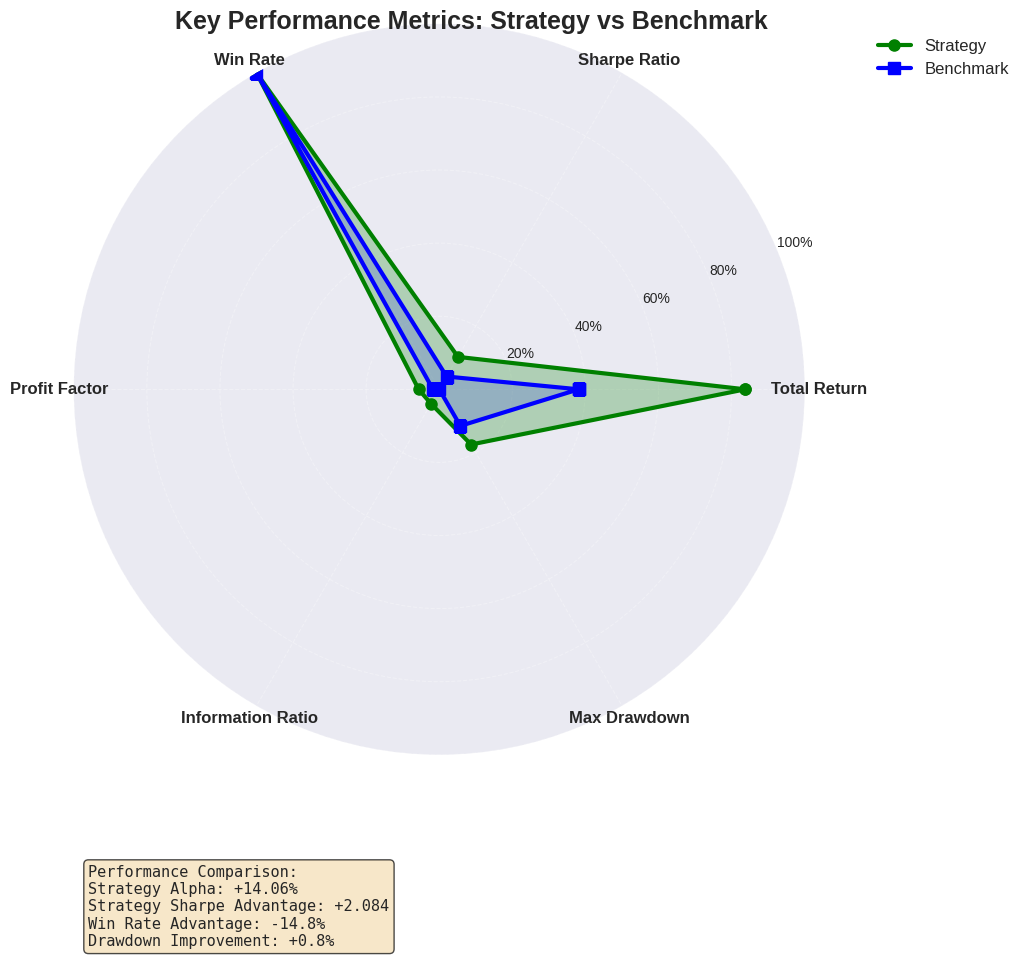

In [ ]:
# Key Performance Metrics Radar Chart

# Create radar chart for key metrics
fig10, ax10 = plt.subplots(figsize=(14, 10), subplot_kw=dict(projection='polar'))
fig10.suptitle('Key Performance Metrics: Strategy vs Benchmark',
              fontsize=18, fontweight='bold', y=0.96)

# Defining metrics for radar chart
metrics = [
    'Total Return',
    'Sharpe Ratio',
    'Win Rate',
    'Profit Factor',
    'Information Ratio',
    'Max Drawdown'
]

# Normalizing values for radar chart (0-1 scale)
def normalize(values, positive_better=True):
    """Normalize values to 0-1 scale"""
    if positive_better:
        min_val = min(values + [0])
        max_val = max(values + [1])
    else:
        # For metrics where lower is better (like drawdown), invert
        min_val = min(values + [0])
        max_val = max(values + [1])
        values = [-v for v in values]  # Invert for normalization

    if max_val == min_val:
        return [0.5] * len(values)

    return [(v - min_val) / (max_val - min_val) for v in values]

# Preparing values
strategy_values = [
    total_strategy_return * 100,  # Converting to percentage
    strategy_sharpe,
    win_rate_strategy * 100,
    min(profit_factor, 5),  # Caping for display
    information_ratio,
    abs(strategy_dd) * 100  # Absolute value for drawdown
]

benchmark_values = [
    total_benchmark_return * 100,
    benchmark_sharpe,
    win_rate_benchmark * 100,
    1,  # Benchmark profit factor
    0,  # Benchmark information ratio
    abs(benchmark_dd) * 100
]

# Normalizing values (higher is better for all after inversion)
strategy_norm = normalize(strategy_values, positive_better=True)
benchmark_norm = normalize(benchmark_values, positive_better=True)

# Seting up radar chart
N = len(metrics)
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]  # Close the polygon

# Duplicating first value to close the circle
strategy_norm += strategy_norm[:1]
benchmark_norm += benchmark_norm[:1]

# Ploting strategy
ax10.plot(angles, strategy_norm, linewidth=3, linestyle='solid',
          label='Strategy', color='green', marker='o', markersize=8)
ax10.fill(angles, strategy_norm, alpha=0.25, color='green')

# Ploting benchmark
ax10.plot(angles, benchmark_norm, linewidth=3, linestyle='solid',
          label='Benchmark', color='blue', marker='s', markersize=8)
ax10.fill(angles, benchmark_norm, alpha=0.15, color='blue')

# Seting radar chart labels
ax10.set_xticks(angles[:-1])
ax10.set_xticklabels(metrics, fontsize=12, fontweight='bold')
ax10.set_ylim(0, 1)
ax10.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
ax10.set_yticklabels(['20%', '40%', '60%', '80%', '100%'], fontsize=10)
ax10.grid(True, alpha=0.3, linestyle='--')

# Adding legend
ax10.legend(loc='upper right', bbox_to_anchor=(1.3, 1.0), fontsize=12)

# Adding actual values as annotations
for i, (metric, s_val, b_val) in enumerate(zip(metrics, strategy_values, benchmark_values)):
    angle = angles[i]

    # Formating values based on metric
    if metric == 'Total Return':
        s_text = f'{s_val:+.1f}%'
        b_text = f'{b_val:+.1f}%'
    elif metric == 'Sharpe Ratio':
        s_text = f'{s_val:.3f}'
        b_text = f'{b_val:.3f}'
    elif metric == 'Win Rate':
        s_text = f'{s_val:.1f}%'
        b_text = f'{b_val:.1f}%'
    elif metric == 'Profit Factor':
        s_text = f'{s_val:.2f}'
        b_text = f'{b_val:.2f}'
    elif metric == 'Information Ratio':
        s_text = f'{s_val:.3f}'
        b_text = f'{b_val:.3f}'
    elif metric == 'Max Drawdown':
        s_text = f'{s_val:.1f}%'
        b_text = f'{b_val:.1f}%'

    # Adding annotations
    ax10.annotate(f'S: {s_text}\nB: {b_text}',
                 xy=(angle, 1.05),
                 xytext=(0, 10),
                 textcoords='offset points',
                 ha='center', va='bottom',
                 fontsize=9, fontweight='bold',
                 bbox=dict(boxstyle='round,pad=0.3', facecolor='wheat', alpha=0.7))

# Adding summary statistics
summary_text = (f'Performance Comparison:\n'
               f'Strategy Alpha: {(total_strategy_return - total_benchmark_return)*100:+.2f}%\n'
               f'Strategy Sharpe Advantage: {strategy_sharpe - benchmark_sharpe:+.3f}\n'
               f'Win Rate Advantage: {(win_rate_strategy - win_rate_benchmark)*100:+.1f}%\n'
               f'Drawdown Improvement: {(benchmark_dd - strategy_dd)*100:+.1f}%')

ax10.text(0.02, -0.15, summary_text,
         transform=ax10.transAxes, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.7),
         fontsize=11, family='monospace')

plt.tight_layout()
plt.savefig('results/10_key_metrics_radar.png', dpi=300, bbox_inches='tight')
plt.show()

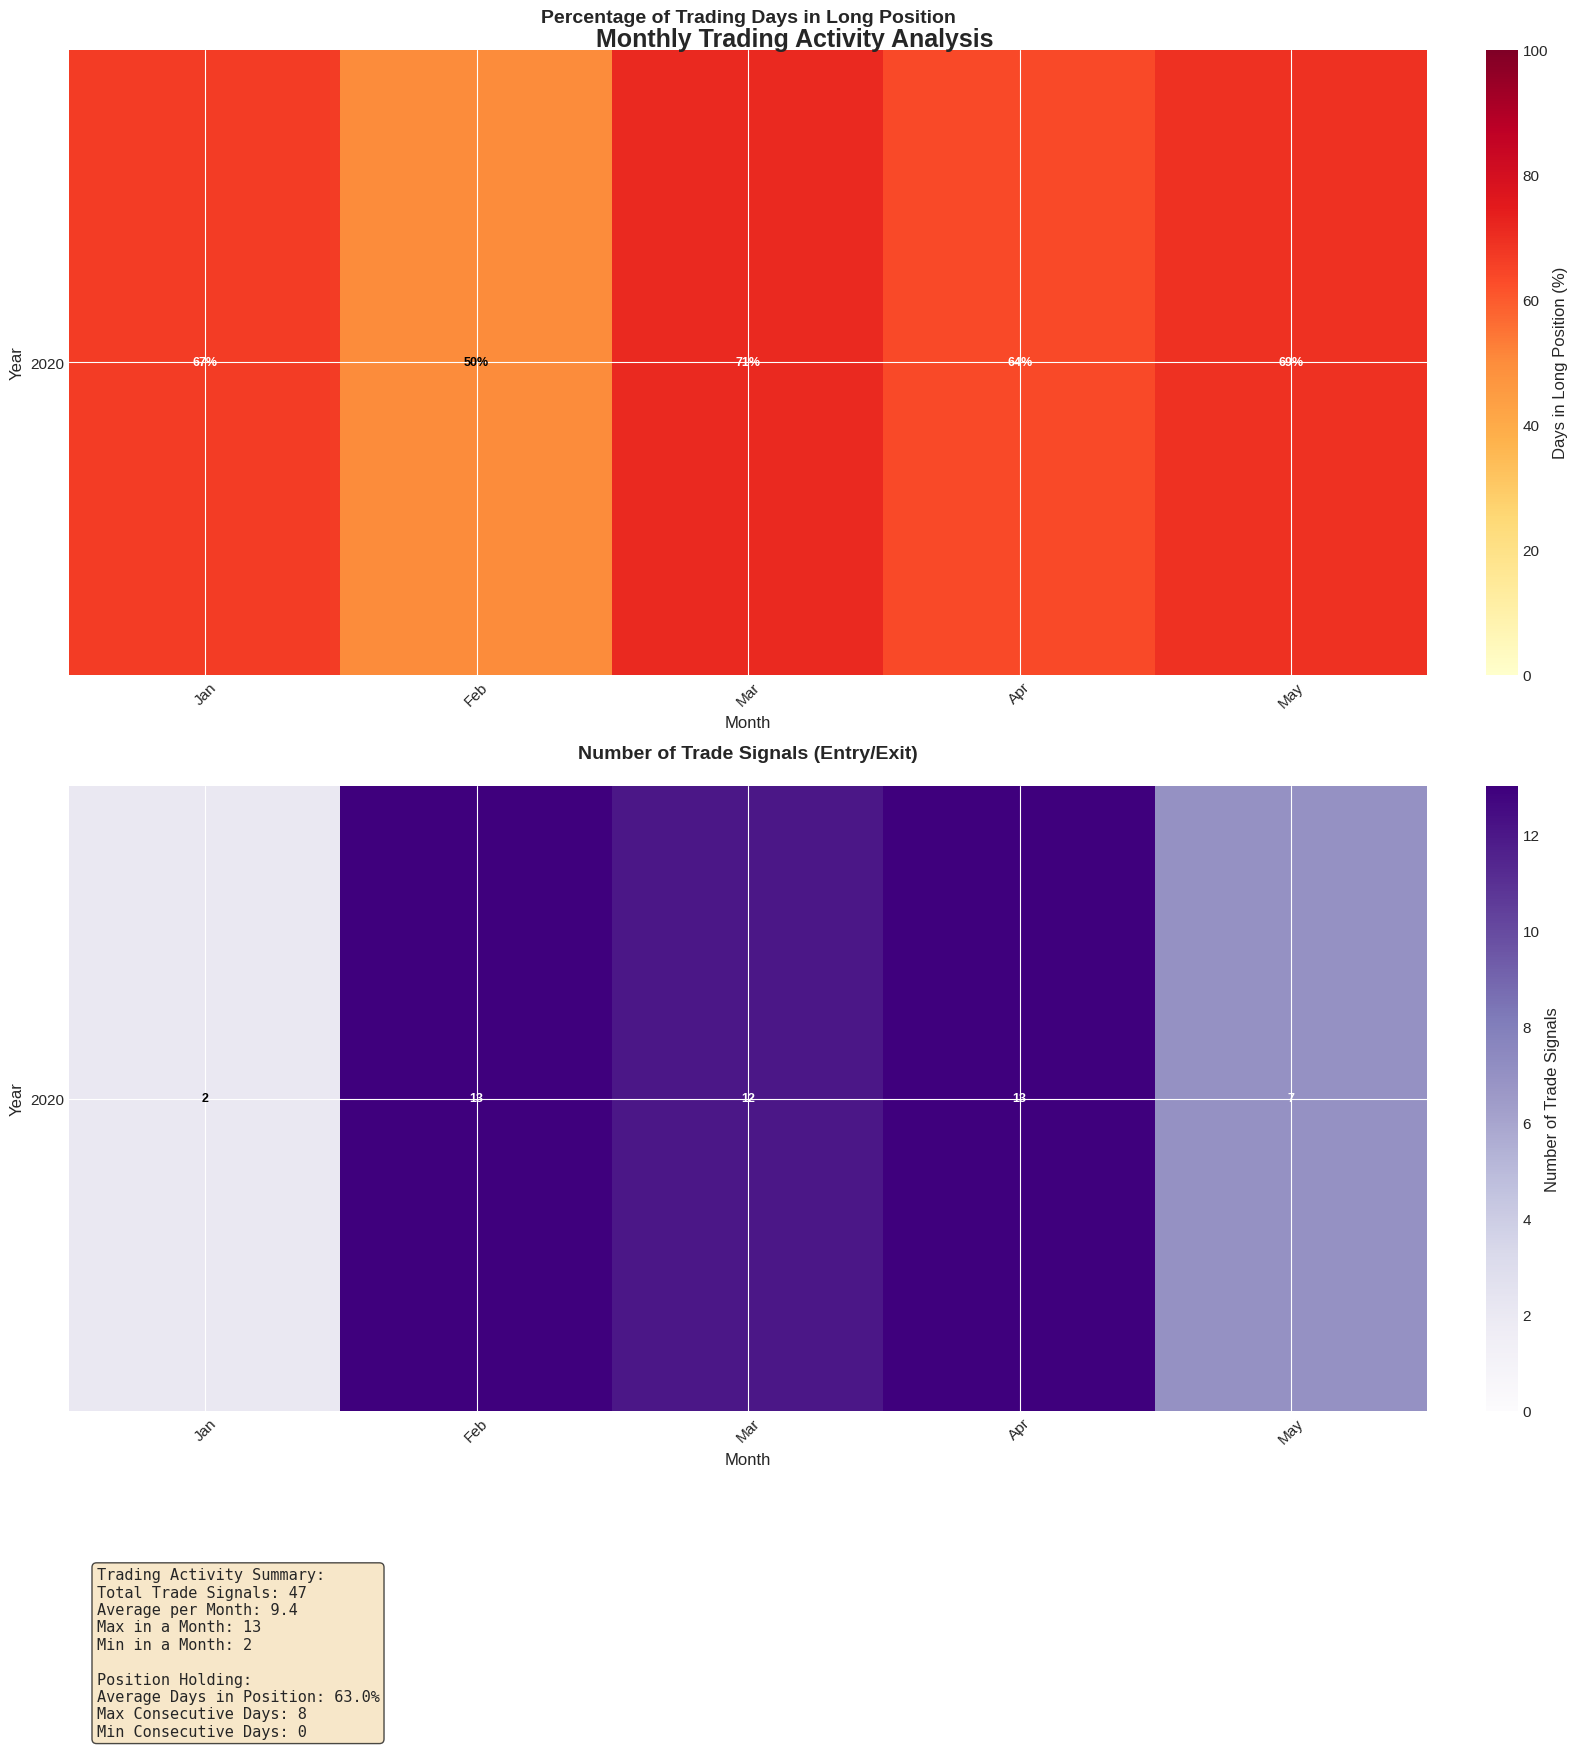

In [ ]:
# Monthly Trading Activity Heatmap

fig11, (ax11a, ax11b) = plt.subplots(2, 1, figsize=(16, 18))
fig11.suptitle('Monthly Trading Activity Analysis',
              fontsize=18, fontweight='bold', y=0.96)

# Preparing monthly trading data
backtest_df['year'] = backtest_df['date'].dt.year
backtest_df['month'] = backtest_df['date'].dt.month
backtest_df['month_name'] = backtest_df['date'].dt.strftime('%b')

# Calculating trades per day (position changes)
backtest_df['trade_signal'] = (backtest_df['position'].diff() != 0).astype(int)

# Subplot 1: Trading days heatmap
trading_days_pivot = backtest_df.pivot_table(
    index='year',
    columns='month',
    values='position',
    aggfunc='mean'
).fillna(0)

im1 = ax11a.imshow(trading_days_pivot * 100, cmap='YlOrRd', aspect='auto',
                   vmin=0, vmax=100, interpolation='nearest')

# Adding text annotations
for i in range(len(trading_days_pivot.index)):
    for j in range(len(trading_days_pivot.columns)):
        value = trading_days_pivot.iloc[i, j] * 100
        if not pd.isna(value):
            text_color = 'white' if value > 50 else 'black'
            ax11a.text(j, i, f'{value:.0f}%',
                      ha='center', va='center',
                      color=text_color, fontsize=9, fontweight='bold')

ax11a.set_title('Percentage of Trading Days in Long Position',
               fontsize=14, fontweight='bold', pad=20)
ax11a.set_xlabel('Month', fontsize=12)
ax11a.set_ylabel('Year', fontsize=12)
ax11a.set_xticks(range(len(trading_days_pivot.columns)))
ax11a.set_xticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
                      'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'][:len(trading_days_pivot.columns)],
                      rotation=45, fontsize=11)
ax11a.set_yticks(range(len(trading_days_pivot.index)))
ax11a.set_yticklabels(trading_days_pivot.index, fontsize=11)

cbar1 = plt.colorbar(im1, ax=ax11a, fraction=0.046, pad=0.04)
cbar1.set_label('Days in Long Position (%)', fontsize=12)
cbar1.ax.tick_params(labelsize=11)

# Subplot 2: Trade signals heatmap
trade_signals_pivot = backtest_df.pivot_table(
    index='year',
    columns='month',
    values='trade_signal',
    aggfunc='sum'
).fillna(0)

im2 = ax11b.imshow(trade_signals_pivot, cmap='Purples', aspect='auto',
                   vmin=0, vmax=trade_signals_pivot.max().max(),
                   interpolation='nearest')

# Adding text annotations
for i in range(len(trade_signals_pivot.index)):
    for j in range(len(trade_signals_pivot.columns)):
        value = trade_signals_pivot.iloc[i, j]
        if not pd.isna(value) and value > 0:
            text_color = 'white' if value > trade_signals_pivot.max().max()/2 else 'black'
            ax11b.text(j, i, f'{int(value)}',
                      ha='center', va='center',
                      color=text_color, fontsize=9, fontweight='bold')

ax11b.set_title('Number of Trade Signals (Entry/Exit)',
               fontsize=14, fontweight='bold', pad=20)
ax11b.set_xlabel('Month', fontsize=12)
ax11b.set_ylabel('Year', fontsize=12)
ax11b.set_xticks(range(len(trade_signals_pivot.columns)))
ax11b.set_xticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
                      'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'][:len(trade_signals_pivot.columns)],
                      rotation=45, fontsize=11)
ax11b.set_yticks(range(len(trade_signals_pivot.index)))
ax11b.set_yticklabels(trade_signals_pivot.index, fontsize=11)

cbar2 = plt.colorbar(im2, ax=ax11b, fraction=0.046, pad=0.04)
cbar2.set_label('Number of Trade Signals', fontsize=12)
cbar2.ax.tick_params(labelsize=11)

# Adding trading statistics
total_trades = backtest_df['trade_signal'].sum()
avg_trades_per_month = total_trades / len(backtest_df['year_month'].unique())
max_trades_month = trade_signals_pivot.max().max()
min_trades_month = trade_signals_pivot.min().min()

trading_stats = (f'Trading Activity Summary:\n'
                f'Total Trade Signals: {total_trades}\n'
                f'Average per Month: {avg_trades_per_month:.1f}\n'
                f'Max in a Month: {max_trades_month:.0f}\n'
                f'Min in a Month: {min_trades_month:.0f}\n\n'
                f'Position Holding:\n'
                f'Average Days in Position: {backtest_df["position"].mean()*100:.1f}%\n'
                f'Max Consecutive Days: {backtest_df["position"].astype(bool).astype(int).groupby(backtest_df["position"].ne(backtest_df["position"].shift()).cumsum()).sum().max()}\n'
                f'Min Consecutive Days: {backtest_df["position"].astype(bool).astype(int).groupby(backtest_df["position"].ne(backtest_df["position"].shift()).cumsum()).sum().min()}')

ax11b.text(0.02, -0.25, trading_stats,
          transform=ax11b.transAxes, verticalalignment='top',
          bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.7),
          fontsize=11, family='monospace')

plt.tight_layout()
plt.savefig('results/11_monthly_trading_activity.png', dpi=300, bbox_inches='tight')
plt.show()

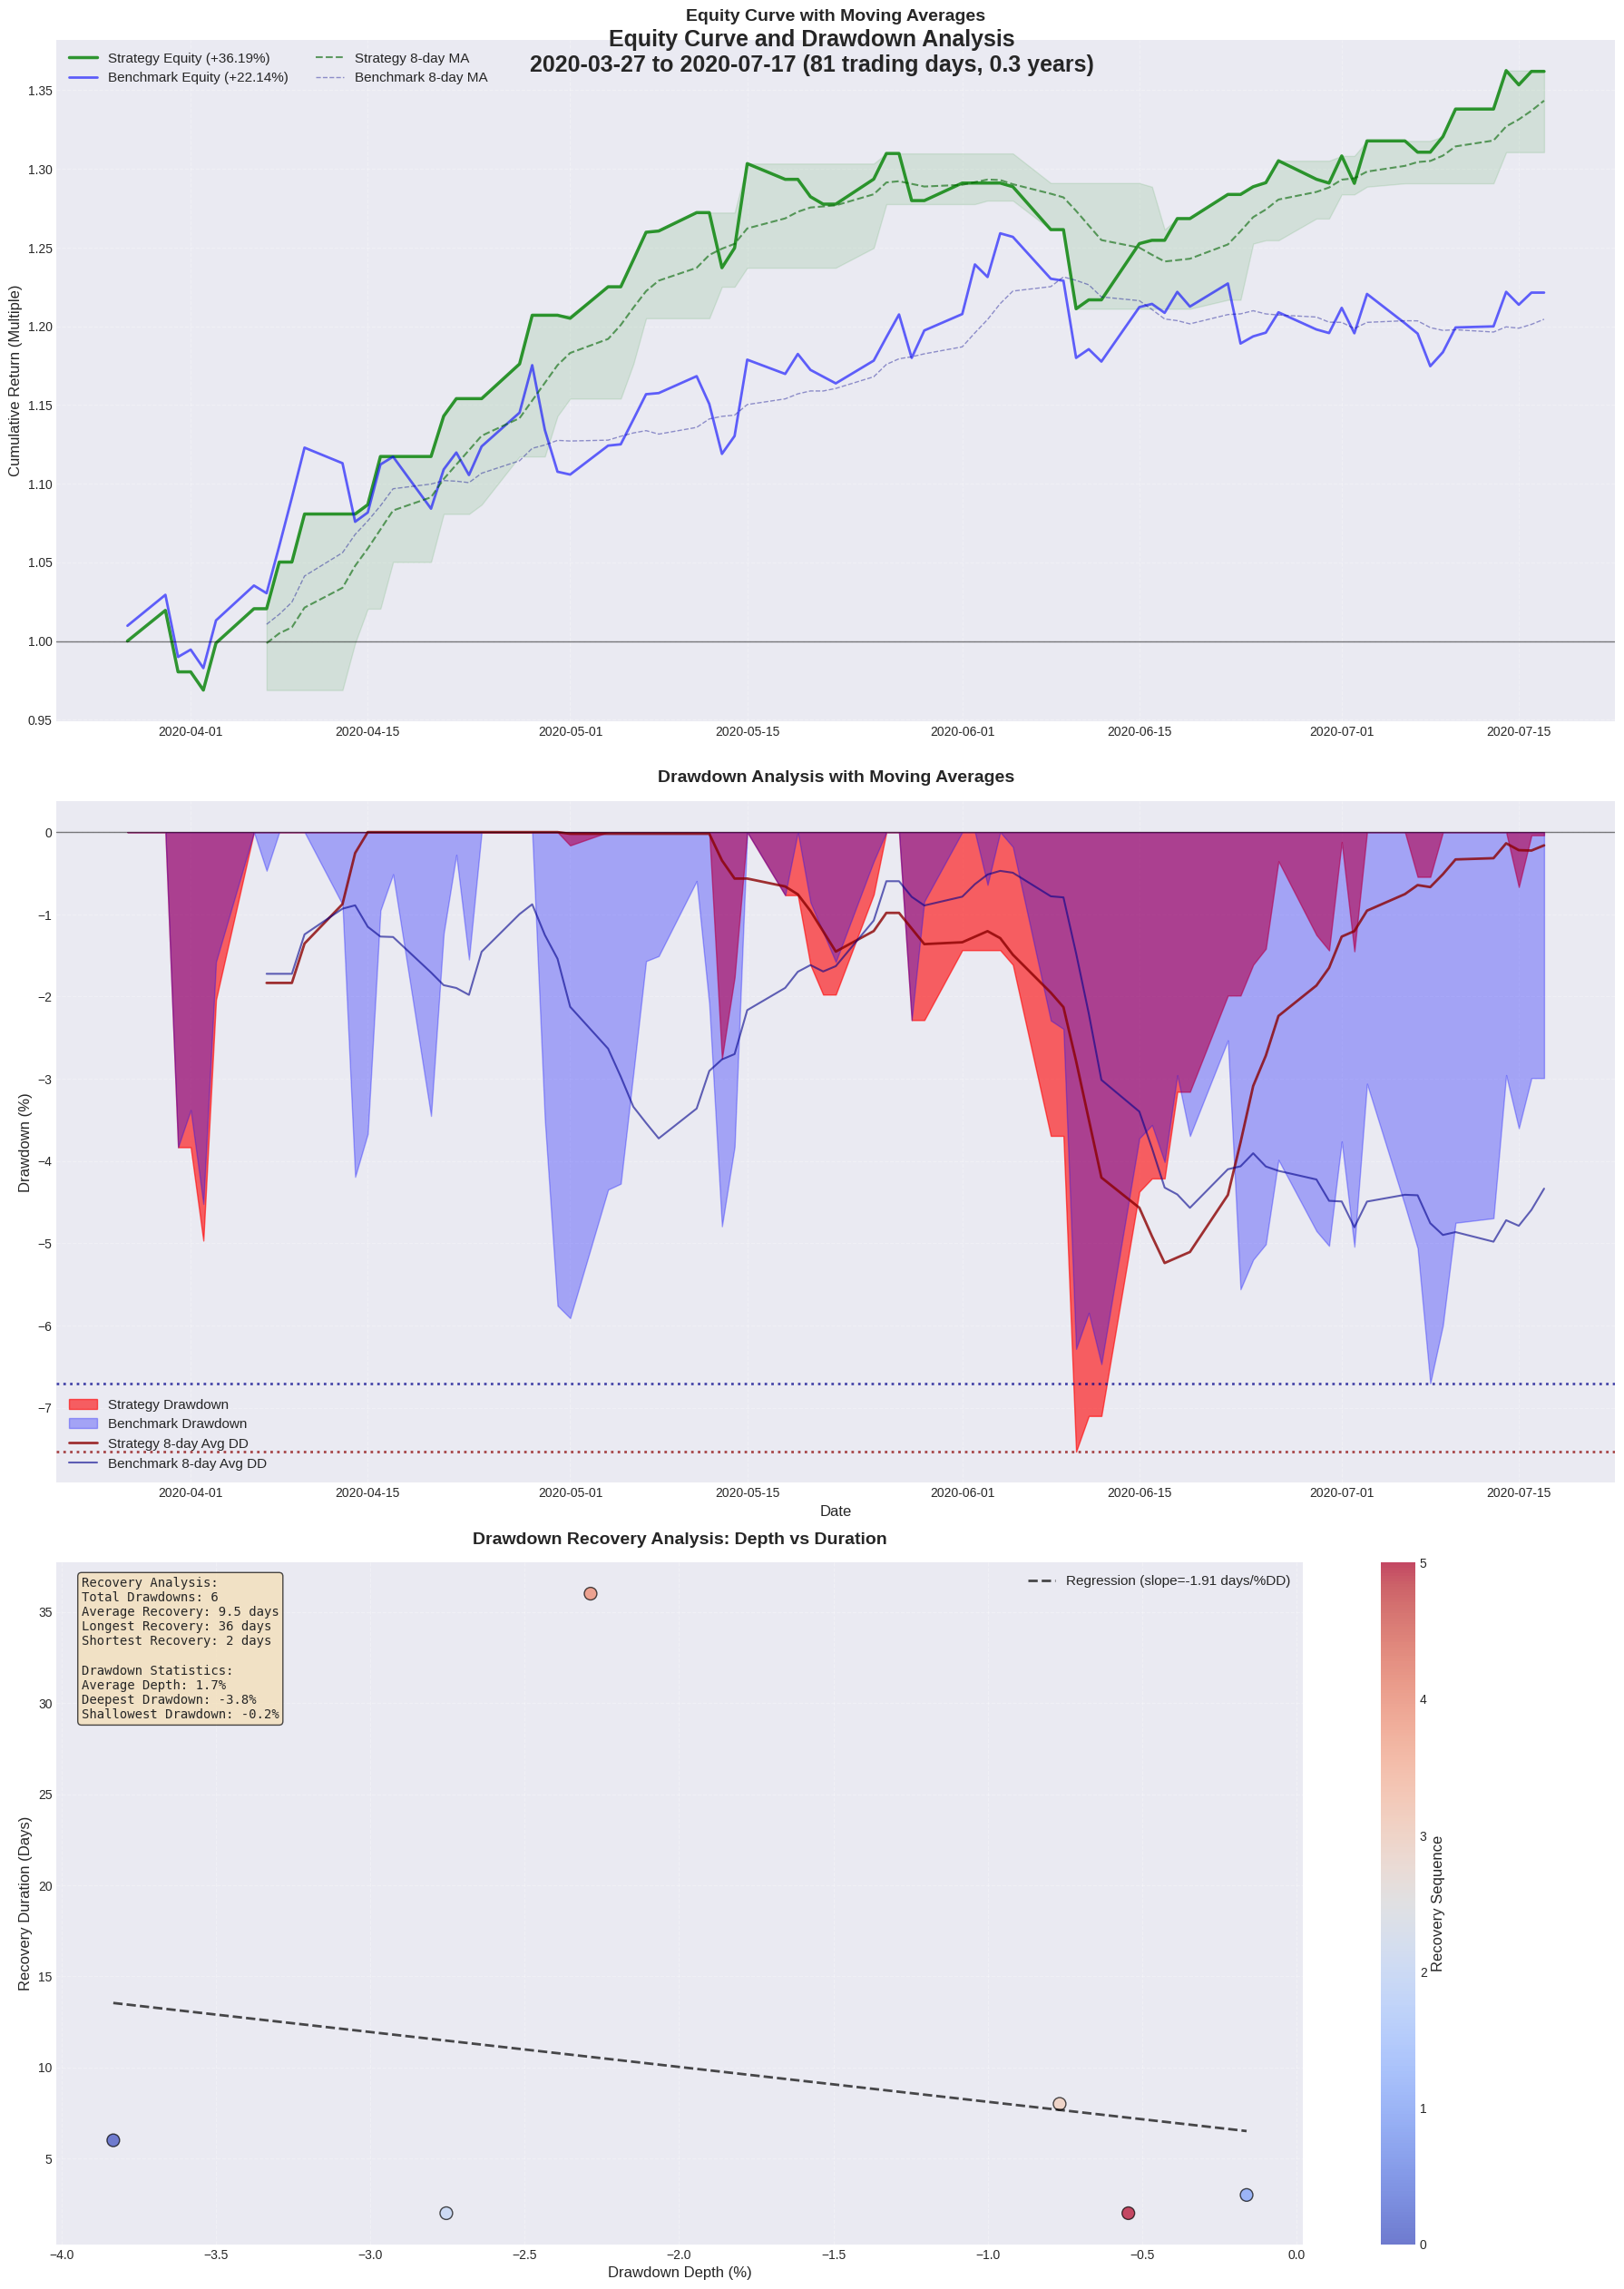

In [ ]:
# Equity Curve with Drawdown

fig12, (ax12a, ax12b, ax12c) = plt.subplots(3, 1, figsize=(18, 26))
fig12.suptitle(f'Equity Curve and Drawdown Analysis\n{backtest_df["date"].min().date()} to {backtest_df["date"].max().date()} ({total_trading_days} trading days, {total_years:.1f} years)',
              fontsize=18, fontweight='bold', y=0.96)

# Calculating rolling metrics
window_size = min(20, len(backtest_df) // 10)  # Adaptive window

# Subplot 1: Equity Curve with Moving Average
ax12a.plot(backtest_df['date'], backtest_df['cumulative_strategy'],
          label=f'Strategy Equity ({total_strategy_return:+.2%})',
          linewidth=2.5, color='green', alpha=0.8)
ax12a.plot(backtest_df['date'], backtest_df['cumulative_benchmark'],
          label=f'Benchmark Equity ({total_benchmark_return:+.2%})',
          linewidth=2, color='blue', alpha=0.6)

# Adding moving averages
if window_size > 1:
    strategy_ma = backtest_df['cumulative_strategy'].rolling(window=window_size).mean()
    benchmark_ma = backtest_df['cumulative_benchmark'].rolling(window=window_size).mean()

    ax12a.plot(backtest_df['date'], strategy_ma,
              label=f'Strategy {window_size}-day MA',
              linewidth=1.5, color='darkgreen', alpha=0.6, linestyle='--')
    ax12a.plot(backtest_df['date'], benchmark_ma,
              label=f'Benchmark {window_size}-day MA',
              linewidth=1, color='darkblue', alpha=0.4, linestyle='--')

ax12a.set_title('Equity Curve with Moving Averages',
               fontsize=14, fontweight='bold', pad=15)
ax12a.set_ylabel('Cumulative Return (Multiple)', fontsize=12)
ax12a.legend(loc='upper left', fontsize=11, ncol=2)
ax12a.grid(True, alpha=0.3, linestyle='--')
ax12a.axhline(y=1, color='black', linestyle='-', alpha=0.5, linewidth=1)

# Adding performance bands (support and resistance)
strategy_high = backtest_df['cumulative_strategy'].rolling(window=window_size).max()
strategy_low = backtest_df['cumulative_strategy'].rolling(window=window_size).min()

ax12a.fill_between(backtest_df['date'], strategy_low, strategy_high,
                  alpha=0.1, color='green', label=f'{window_size}-day Range')

# Subplot 2: Drawdown Analysis
strategy_drawdown = (backtest_df['cumulative_strategy'] /
                     backtest_df['cumulative_strategy'].cummax() - 1) * 100
benchmark_drawdown = (backtest_df['cumulative_benchmark'] /
                      backtest_df['cumulative_benchmark'].cummax() - 1) * 100

# Filling drawdown areas
ax12b.fill_between(backtest_df['date'], strategy_drawdown, 0,
                  alpha=0.6, color='red', label='Strategy Drawdown')
ax12b.fill_between(backtest_df['date'], benchmark_drawdown, 0,
                  alpha=0.3, color='blue', label='Benchmark Drawdown')

# Adding moving average of drawdown
if window_size > 1:
    strategy_dd_ma = strategy_drawdown.rolling(window=window_size).mean()
    benchmark_dd_ma = benchmark_drawdown.rolling(window=window_size).mean()

    ax12b.plot(backtest_df['date'], strategy_dd_ma,
              label=f'Strategy {window_size}-day Avg DD',
              linewidth=2, color='darkred', alpha=0.8)
    ax12b.plot(backtest_df['date'], benchmark_dd_ma,
              label=f'Benchmark {window_size}-day Avg DD',
              linewidth=1.5, color='darkblue', alpha=0.6)

ax12b.set_title('Drawdown Analysis with Moving Averages',
               fontsize=14, fontweight='bold', pad=15)
ax12b.set_ylabel('Drawdown (%)', fontsize=12)
ax12b.set_xlabel('Date', fontsize=12)
ax12b.legend(loc='lower left', fontsize=11)
ax12b.grid(True, alpha=0.3, linestyle='--')
ax12b.axhline(y=0, color='black', linestyle='-', alpha=0.5, linewidth=1)

# Adding max drawdown lines
ax12b.axhline(y=strategy_dd * 100, color='darkred', linestyle=':',
             alpha=0.7, linewidth=2, label=f'Strategy Max DD: {strategy_dd:+.1f}%')
ax12b.axhline(y=benchmark_dd * 100, color='darkblue', linestyle=':',
             alpha=0.7, linewidth=2, label=f'Benchmark Max DD: {benchmark_dd:+.1f}%')

# Subplot 3: Recovery Periods Analysis
# Identifying drawdown periods
strategy_drawdown_series = pd.Series(strategy_drawdown, index=backtest_df['date'])
drawdown_periods = strategy_drawdown_series < 0

# Calculating recovery times
recovery_data = []
current_drawdown = None
recovery_start = None

for date, dd in zip(backtest_df['date'], strategy_drawdown):
    if dd < 0 and current_drawdown is None:
        # Start of new drawdown
        current_drawdown = dd
        recovery_start = date
    elif dd >= 0 and current_drawdown is not None:
        # End of drawdown (recovery)
        recovery_days = (date - recovery_start).days
        recovery_data.append({
            'start': recovery_start,
            'end': date,
            'depth': current_drawdown,
            'duration': recovery_days
        })
        current_drawdown = None
        recovery_start = None

# Ploting recovery periods as bars
if recovery_data:
    recovery_df = pd.DataFrame(recovery_data)

    # Ploting recovery duration vs drawdown depth
    scatter = ax12c.scatter([rd['depth'] for rd in recovery_data],
                           [rd['duration'] for rd in recovery_data],
                           c=range(len(recovery_data)),
                           cmap='coolwarm', s=100, alpha=0.7,
                           edgecolors='black', linewidth=1)

    # Adding regression line
    if len(recovery_data) > 2:
        depths = [rd['depth'] for rd in recovery_data]
        durations = [rd['duration'] for rd in recovery_data]
        z = np.polyfit(depths, durations, 1)
        p = np.poly1d(z)

        x_line = np.linspace(min(depths), max(depths), 100)
        ax12c.plot(x_line, p(x_line), 'k--', alpha=0.7, linewidth=2,
                  label=f'Regression (slope={z[0]:.2f} days/%DD)')

    ax12c.set_title('Drawdown Recovery Analysis: Depth vs Duration',
                   fontsize=14, fontweight='bold', pad=15)
    ax12c.set_xlabel('Drawdown Depth (%)', fontsize=12)
    ax12c.set_ylabel('Recovery Duration (Days)', fontsize=12)
    ax12c.grid(True, alpha=0.3, linestyle='--')
    ax12c.legend(loc='upper right', fontsize=11)

    # Adding colorbar for recovery sequence
    cbar = plt.colorbar(scatter, ax=ax12c)
    cbar.set_label('Recovery Sequence', fontsize=12)

    # Adding recovery statistics
    avg_recovery = np.mean([rd['duration'] for rd in recovery_data])
    max_recovery = np.max([rd['duration'] for rd in recovery_data])
    min_recovery = np.min([rd['duration'] for rd in recovery_data])

    recovery_stats = (f'Recovery Analysis:\n'
                     f'Total Drawdowns: {len(recovery_data)}\n'
                     f'Average Recovery: {avg_recovery:.1f} days\n'
                     f'Longest Recovery: {max_recovery} days\n'
                     f'Shortest Recovery: {min_recovery} days\n\n'
                     f'Drawdown Statistics:\n'
                     f'Average Depth: {np.mean([abs(rd["depth"]) for rd in recovery_data]):.1f}%\n'
                     f'Deepest Drawdown: {min([rd["depth"] for rd in recovery_data]):.1f}%\n'
                     f'Shallowest Drawdown: {max([rd["depth"] for rd in recovery_data]):.1f}%')

    ax12c.text(0.02, 0.98, recovery_stats,
              transform=ax12c.transAxes, verticalalignment='top',
              bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.7),
              fontsize=10, family='monospace')
else:
    ax12c.text(0.5, 0.5, 'No complete drawdown-recovery cycles\nin the backtest period',
              ha='center', va='center', fontsize=14)
    ax12c.set_title('Drawdown Recovery Analysis',
                   fontsize=14, fontweight='bold', pad=15)

plt.tight_layout()
plt.savefig('results/12_equity_curve_drawdown.png', dpi=300, bbox_inches='tight')
plt.show()

Downloading the files

In [ ]:
!zip -r results.zip results/

from google.colab import files
files.download('results.zip')